# 📊 Trabalho Final: Redes Neurais Profundas
**Universidade Federal de Goiás (UFG) — Instituto de Informática (INF)**

**Projeto:** Análise Arquitetural do Congelamento de Camadas na Mitigação de *Domain Shift* e *Language Shift* em Transformers Multilíngues

**Equipe:**
- Geovana Teixeira Camargo — 202303338
- Sebastião Corrêa Fraga Neto — 202301487
- Pedro Reis Pimenta — 202303359
- Henrique Matheus Mendonça de Miranda — 202402479

---
> **Sobre este notebook:** versão única que consolida os quatro notebooks do projeto (Etapas 0 a 4), reorganizada no formato de artigo:
>
> | Seção | Conteúdo |
> |---|---|
> | **1. Problema** | Contexto, lacuna, pergunta de pesquisa e hipóteses |
> | **2. Métodos** | Decisões travadas, limitações atuais e a pipeline executável (Etapas 0–3) |
> | **3. Resultados** | Análise estatística da Etapa 4 sobre as 48 medições: tabelas, testes (Welch *t*, Mann-Whitney U, Cohen's *d*), veredito e gráficos — já executados |
> | **4. Conclusão** | Veredito formal das hipóteses, amarrado às evidências e ao escopo das limitações |
> | **5. Próximos passos** | Encaminhamentos decorrentes das limitações |
>
> A Seção 3 é **autossuficiente**: o `results.csv` está embutido e as células já vêm executadas — não exige GPU, Google Drive nem reexecutar o treino.

---
# 1. Problema (*Research Question*)

### 1.1 Contexto e Lacuna (*The Gap*)
Em tarefas de NLP, modelos pré-treinados em múltiplos idiomas (como o **XLM-RoBERTa**) são eficazes, mas sofrem degradação de performance quando o **domínio** (ex.: de Eletrônicos para Beleza/Saúde) ou o **idioma** (ex.: de Inglês para Português) muda entre o treino e o teste (*Zero-shot cross-lingual*).

A lacuna reside em entender como o **congelamento seletivo de camadas** (inicial vs. final) pode preservar o conhecimento linguístico e semântico para mitigar essas quedas de performance.

### 1.2 Pergunta de Pesquisa
> *"Em tarefas de classificação binária de sentimento, qual estratégia de congelamento seletivo de pesos em um XLM-RoBERTa mitiga mais eficazmente a degradação de F1-macro causada por Language Shift versus Domain Shift?"*

### 1.3 Hipóteses
- **H1 (Language Shift):** Congelar camadas iniciais (0–5) mitiga a queda entre Inglês e Português.
- **H2 (Domain Shift):** Congelar camadas finais (6–11) mitiga a queda entre os domínios de Eletrônicos e Beleza/Saúde.

---
# 2. Métodos

Esta seção detalha o delineamento experimental construído para investigar as causas da degradação de performance em modelos de PLN quando submetidos a cenários reais de transferência *Zero-Shot Cross-Lingual*. A abordagem foca na manipulação estrutural da arquitetura base (**XLM-RoBERTa**) durante o *fine-tuning*, buscando isolar e quantificar o impacto de duas variáveis independentes: a alteração do idioma (*Language Shift*) e a mudança da semântica da tarefa (*Domain Shift*).

### 2.1 Arquitetura do Modelo
Utilizaremos o **XLM-RoBERTa-base** (~278M parâmetros) com a *classification head* padrão do Hugging Face (Dropout → Dense 768→768 → tanh → Dropout → Linear; 592.130 parâmetros) para classificação binária (Positivo/Negativo).

## ✅ O que está definido até agora (decisões travadas)

| Bloco | Decisão travada |
|---|---|
| Pergunta e desenho | Matriz 2×2 (idioma × domínio): treina em EN/Eletrônicos; testa em **T1** EN/Eletrônicos (controle), **T2** EN/Beleza (*Domain Shift*), **T3** PT/Eletrônicos (*Language Shift*), **T4** PT/Beleza (combinado) |
| Tarefa e rótulos | Sentimento binário: 1–2★ = Negativo, 4–5★ = Positivo, 3★ descartada (ambígua) |
| Modelo | XLM-RoBERTa-base (12 camadas, ~278M parâmetros) + *classification head* padrão do Hugging Face (592.130 parâmetros, sempre treinável) |
| Dados e domínios | EN: `amazon_polarity` filtrado por palavra-chave (precisão auditada: 90% / 94%) · PT: B2W filtrado pela **categoria oficial** `site_category_lv1` (ground-truth) · Domínios **Eletrônicos × Beleza** — 3ª iteração, escolhida por dados na Etapa 0 (Logística reprovou na auditoria com 52%; Livros derrubava o treino para 358 amostras) |
| Balanceamento | **Desacoplado**: treino no próprio máximo (**10.718** exemplos, split 80/20) e as 4 células de teste niveladas em **2.680** cada (1.340/classe) |
| Configurações | **C1** Full Fine-Tuning (100% treinável) · **C2** Freeze Lower: congela embeddings + camadas 0–5 (treina 15,5%) · **C3** Freeze Upper: congela camadas 6–11 (treina 84,7%) · **C4** Frozen Encoder: só a head (0,21%) |
| Protocolo de treino | AdamW · LR 2e-5 · batch 16 · max_len 128 · weight decay 0,01 · warmup 10% · ≤3 épocas · early stopping (paciência 1 em `eval_loss`, sobre um `val'` interno de 10% — **sem vazamento para T1**) · fp16 · seeds {42, 123, 2024} |
| Execução realizada | **12 fine-tunings** (4 configs × 3 seeds) em GPU T4, com avaliação inline nas 4 células → **`results.csv` com 48 medições** · análise estatística completa (Etapa 4) na Seção 3 |

**Em aberto:** análise dedicada das palavras ambíguas do filtro EN e a avaliação em uma língua tipologicamente distante (teste de refutação — ver Seção 5).

## ⚠️ Limitações atuais e o que está impactando os resultados

1. **Filtro lexical no lado EN e palavras ambíguas.** O `amazon_polarity` não traz a categoria do produto, então o domínio é atribuído por palavras-chave no texto. Os termos polissêmicos mais problemáticos já foram removidos (`screen`, `camera`, `display`, `speaker`, `keyboard`, `processor` vazavam para reviews de filme/música/cozinha), mas a polissemia residual é inerente ao método. **Impacto:** ~6–10% de ruído de domínio em S1/S2 (precisão auditada de 90% e 94%). Como T1 e T2 saem do mesmo filtro, os dois conjuntos ficam *mais parecidos* que os domínios reais, o que **subestima** a magnitude verdadeira do *Domain Shift* — o Δ medido é um piso, não o valor real.
2. **Atribuição de domínio assimétrica.** EN por palavra-chave (proxy imperfeita) e PT pela categoria oficial do produto (ground-truth, ~100%). **Impacto:** o "ganho zero-shot" em PT está **confundido** com o fato de o conjunto PT ser mais limpo de rotular — é a limitação mais séria para a leitura de H1.
3. **Par linguístico único (EN→PT).** Inglês e português são línguas próximas (indo-europeias, escrita latina) e massivamente representadas no pré-treino do XLM-R. **Impacto:** o achado de *language shift* nulo vale para ESTE par; uma língua tipologicamente distante poderia refutá-lo (ver Seções 4 e 5).
4. **n = 3 seeds**, por restrição computacional. **Impacto:** menor robustez estatística — o Mann-Whitney U satura em p=0,10 com n=3; reportamos Cohen's *d* (efeitos grandes) para compensar.
5. **Apenas XLM-R-base.** **Impacto:** a dinâmica de congelamento pode diferir em modelos maiores.
6. **Células de teste com 2.680 exemplos** (abaixo do teto ideal de 5.000). **Impacto:** intervalos de confiança mais largos.
7. **Binarização das estrelas** (descarte da nota 3). **Impacto:** o problema fica mais "limpo" que o cenário real.
8. **Hiperparâmetros fixos entre as configurações** (LR 2e-5 em todas). **Impacto:** configs com congelamento parcial poderiam render mais com LR maior; o C4 (frozen encoder), em especial, pode estar subtreinado.

## 🔁 Pipeline executável (Etapas 0–3)

As subseções a seguir preservam, na ordem de execução, os quatro notebooks originais do projeto. Cada etapa é autocontida: instala as próprias dependências e monta o Google Drive quando necessário.

> ⚠️ **Não é preciso reexecutar nada para ver os resultados:** o produto desta pipeline (`results.csv`, 48 medições) já está embutido e analisado na **Seção 3**. A reexecução completa do treino (Etapa 3, 12 fine-tunings) leva ~1,5–2,5 h em GPU T4 e só é necessária para reproduzir o experimento do zero — e o loop é **idempotente**: runs já registrados no `results.csv` do Drive são pulados automaticamente.

## 🔎 Etapa 0 — Exploração Prévia de Domínios Candidatos

Este notebook ajuda a escolher **com base em dados** quais domínios (categorias) devem ser usados no experimento de *Domain Shift* e *Language Shift*.

A escolha incorreta dos domínios (ex: "Livros") pode causar problemas nas etapas seguintes porque a base em Português (B2W/Olist) pode ter um número irrisório de **avaliações negativas** para aquela categoria, forçando todo o subconjunto de testes (e às vezes de treino) a ter um tamanho muito reduzido devido à regra de balanceamento.

## Objetivo deste script:
Baixar a base do B2W, mapear os rótulos de sentimento e descobrir quais as maiores categorias, focando naquelas que possuem um número mais robusto na classe minoritária (quase sempre a negativa).


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download do B2W
CAMINHO_B2W = "/content/b2w.csv"
URL_B2W = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"

print("📥 Baixando B2W Reviews...")
if not os.path.exists(CAMINHO_B2W):
    if not os.path.exists("/content"):
        os.makedirs("/content", exist_ok=True)
    df_b2w = pd.read_csv(URL_B2W, low_memory=False)
    df_b2w.to_csv(CAMINHO_B2W, index=False)
else:
    df_b2w = pd.read_csv(CAMINHO_B2W, low_memory=False)
    
print(f"✅ Base B2W carregada com {df_b2w.shape[0]:,} avaliações.")

In [ ]:
# 2. Mapeamento de Rótulos
def estrela_para_sentimento(nota):
    try:
        n = float(nota)
    except (TypeError, ValueError):
        return None
    if n <= 2: return 'Negativo'  # 0 no script final, mas string ajuda na visualizacao aqui
    if n >= 4: return 'Positivo'  # 1 no script final
    return None

df_b2w['label'] = df_b2w['overall_rating'].apply(estrela_para_sentimento)
df_b2w_validos = df_b2w.dropna(subset=['label']).copy()

print(f"🔹 Após descartar notas 3 (neutras) e nulas, sobraram {df_b2w_validos.shape[0]:,} avaliações.")
print(df_b2w_validos['label'].value_counts())

In [ ]:
# 3. Agrupamento por Categoria (site_category_lv1)
# Vamos descobrir quais categorias têm uma boa representação nas DUAS classes.

# Tabela Pivot: Categorias x Sentimentos
tabela_categorias = pd.crosstab(df_b2w_validos['site_category_lv1'], df_b2w_validos['label'])

# O Gargalo é o mínimo entre Positivos e Negativos, 
# já que o modelo precisará fazer undersampling (balanceamento) por classe
tabela_categorias['Gargalo (Balanceado)'] = tabela_categorias.min(axis=1)
tabela_categorias['Total'] = tabela_categorias['Negativo'] + tabela_categorias['Positivo']

# Ordenando pelo gargalo (aquelas que nos permitirão o maior número final equilibrado)
tabela_categorias = tabela_categorias.sort_values(by='Gargalo (Balanceado)', ascending=False)

print("🏆 TOP 15 Categorias mais 'seguras' para serem escolhidas como domínio (ordenadas pelo gargalo):\n")
display(tabela_categorias.head(15))

In [ ]:
# 4. Visualização
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

top_10 = tabela_categorias.head(10).reset_index()

# Plotando barras do 'Gargalo (Balanceado)'
ax = sns.barplot(x='Gargalo (Balanceado)', y='site_category_lv1', data=top_10, color='royalblue')
plt.title('Top 10 Categorias por Amostras Balanceadas (Amostras da Classe Minoritária)', fontsize=14)
plt.xlabel('Número máximo de amostras possíveis por classe (Balanceado)', fontsize=12)
plt.ylabel('Categoria (B2W)', fontsize=12)

# Anotando o número nos gráficos
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha = 'left', va = 'center', 
                xytext = (5, 0), 
                textcoords = 'offset points')

plt.show()

## 💡 Como interpretar os resultados acima:

- As categorias no topo da lista possuem as maiores margens de segurança para gerar as partições `S3` (Domínio 1 - PT) e `S4` (Domínio 2 - PT).
- Se a categoria escolhida tem um 'Gargalo' de 10.000, isso significa que você conseguirá extrair no máximo 10.000 amostras positivas e 10.000 negativas (20.000 no total) daquela categoria.
- Você deve escolher **duas** categorias do topo que sejam **semanticamente distintas** (por exemplo: Celulares vs Beleza & Saúde). E certificar-se de que a Amazon Reviews americana também possua boas amostras nesses dois domínios.

A partir dessa escolha, você deve mapear as *keywords* associadas na etapa seguinte (Etapa 1).

---
## 🟦 Etapa 1 — Preparação de Dados e Auditoria Semântica

Esta etapa implementa as três *tasks* do plano de execução:

| Task | Descrição | Saída |
|------|-----------|-------|
| **1.1** | Download e exploração inicial dos datasets (Amazon EN, B2W PT) | Pools carregados + EDA |
| **1.2** | Filtragem por domínio (EN: keyword · PT: categoria) → partições **S1, S2, S3, S4** | Subconjuntos sem interseção de IDs |
| **1.3** | Auditoria de qualidade via LLM zero-shot (100 amostras/subconjunto) | Tabela de precisão (≥ 80%) |

**Subconjuntos-alvo** (Seção 5.4 da Metodologia):

| ID | Origem | Idioma | Domínio | Função |
|----|--------|--------|---------|--------|
| **S1** | Amazon (keyword) | EN | Eletrônicos | Treino (80%) + Validação (20%) |
| **S2** | Amazon (keyword) | EN | Beleza | Teste — isola *Domain Shift* |
| **S3** | B2W (categoria) | PT | Eletrônicos | Teste — isola *Language Shift* |
| **S4** | B2W (categoria) | PT | Beleza | Teste — impacto combinado |

**Esquema de rótulos** (Seção 4): estrelas 1–2 → **Negativo (0)**, 4–5 → **Positivo (1)**, nota 3 descartada.

### 2.0 Configuração do Ambiente

In [ ]:
# 1. Instalação das bibliotecas necessárias
#    (datasets<3.0.0 mantém compatibilidade com leitura via streaming usada aqui)
!pip install -q "transformers" "datasets<3.0.0" evaluate accelerate scikit-learn matplotlib seaborn
print("Bibliotecas instaladas.")

In [ ]:
# 2. Hardware e Fixação de Seeds (Seção 10 da Metodologia)
import torch, random, os
import numpy as np
from transformers import set_seed
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware em uso: {device}")

SEEDS = [42, 123, 2024]   # seeds oficiais do projeto (usadas nas Etapas 3-4)
SEED_DATA = 42            # seed da preparação de dados (amostragem / balanceamento)

def fixar_seed(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    set_seed(seed)

fixar_seed(SEED_DATA)
print(f"Seeds do projeto: {SEEDS} | Seed da preparação de dados: {SEED_DATA}")

In [ ]:
# 3. Parâmetros centrais da Etapa 1
from pathlib import Path

DIR_SAIDA = Path("/content/data_processed")
DIR_SAIDA.mkdir(parents=True, exist_ok=True)

# Mapeamento estrela -> sentimento binário (Seção 4): 1,2->0(Neg) | 4,5->1(Pos) | 3 descartado
def estrela_para_sentimento(nota):
    try:
        n = float(nota)
    except (TypeError, ValueError):
        return None
    if n <= 2: return 0
    if n >= 4: return 1
    return None  # nota 3 (neutra) descartada

MAX_CANDIDATOS_EN = 20000      # candidatos coletados por domínio EN (antes do balanceamento)
MAX_LINHAS_STREAM_EN = 600000  # teto de linhas varridas no stream do Amazon
N_AUDITORIA = 100              # amostras por subconjunto para auditoria manual (Task 1.3)
LIMIAR_PRECISAO = 0.80         # critério de aceitação do filtro
print("Configurações carregadas.")

### 2.2 Definição de Domínios — EN por palavra-chave, PT por categoria

A atribuição de domínio usa **dois métodos**, um por base, conforme a disponibilidade de metadado:

- **Inglês (Amazon `amazon_polarity`)** — não traz categoria de produto, então usamos **filtro lexical**: a avaliação pertence a um domínio se contém ≥1 palavra-chave dele **e nenhuma** do outro (descarta ambíguos/neutros).
- **Português (B2W)** — traz `site_category_lv1`, então usamos **a categoria do produto** diretamente (ground-truth, precisão ~100%), eliminando o viés do filtro lexical justamente no lado mais escasso.

Essa assimetria é proposital: aproveita o metadado onde ele existe (PT) e mantém o método lexical onde não existe (EN). A auditoria zero-shot (Task 1.3) valida a precisão do lado EN; o lado PT é exato por construção.

> **Por que isso importa:** o filtro por keyword em PT capturava só ~300 avaliações negativas de beleza; a categoria `Beleza e Perfumaria` tem **2.372** (descoberto na Etapa 0). O gargalo era o método, não o domínio.

In [ ]:
# Definição dos domínios — Eletrônicos × Beleza
# Abordagem híbrida (declarada na metodologia):
#   • EN (amazon_polarity, SEM metadado de categoria) -> filtro por PALAVRA-CHAVE.
#   • PT (B2W, COM site_category_lv1)                -> filtro por CATEGORIA (ground-truth).

# --- EN: palavras-chave INEQUÍVOCAS de eletrônicos ---
# Removidas as ambíguas (screen, camera, display, speaker, keyboard, processor): elas
# vazavam para reviews de filme/música/cozinha ("on screen", "camera work", "food processor")
# e derrubavam a precisão do filtro EN. Mantidos só termos específicos de eletrônica de consumo.
keywords_eletronicos_en = ['battery','usb','charger','charging','wifi','bluetooth',
                           'smartphone','laptop','tablet','touchscreen','headphone',
                           'headphones','earbuds','smartwatch','phone','phones','router','hdmi']
keywords_beleza_en      = ['skin','scent','fragrance','perfume','cream',
                           'lotion','shampoo','conditioner','moisturizer','makeup',
                           'cosmetic','serum','sunscreen','soap','wrinkle']
KEYWORDS = {'en': {'eletronicos': keywords_eletronicos_en, 'beleza': keywords_beleza_en}}

# --- PT: mapeamento de categoria (site_category_lv1) -> domínio ---
# Eletrônicos = cluster de eletrônica de consumo (parear com a definição ampla do EN).
# Beleza      = Beleza e Perfumaria. Demais categorias -> None (descartadas).
CATEGORIAS_PT = {
    'Celulares e Smartphones':  'eletronicos',
    'Informática e Acessórios': 'eletronicos',
    'TV e Home Theater':        'eletronicos',
    'Beleza e Perfumaria':      'beleza',
}

def categoria_para_dominio(cat):
    """Mapeia site_category_lv1 -> 'eletronicos' | 'beleza' | None."""
    if not isinstance(cat, str):
        return None
    return CATEGORIAS_PT.get(cat.strip(), None)

print("Domínios: EN por keyword (lista enxuta/inequívoca) | PT por categoria (site_category_lv1).")
print("Categorias PT consideradas:", CATEGORIAS_PT)

In [ ]:
# Filtro lexical (usado SÓ no lado EN; o PT usa categoria)
import re

def _compilar_regex(lista_kw):
    partes = [re.escape(kw.lower()) for kw in lista_kw]
    return re.compile(r"\b(?:" + "|".join(partes) + r")\b", re.UNICODE)

REGEX = {lang: {dom: _compilar_regex(kws) for dom, kws in doms.items()}
         for lang, doms in KEYWORDS.items()}

def classificar_dominio(texto, lang='en'):
    # Regra 5.2 (EN): >=1 keyword do domínio E nenhuma do outro
    if not isinstance(texto, str) or not texto.strip():
        return None
    t = texto.lower()
    tem_eletr  = bool(REGEX[lang]['eletronicos'].search(t))
    tem_beleza = bool(REGEX[lang]['beleza'].search(t))
    if tem_eletr and not tem_beleza: return 'eletronicos'
    if tem_beleza and not tem_eletr: return 'beleza'
    return None

# Sanity checks — EN (keyword)
assert classificar_dominio("the battery life is amazing", 'en') == 'eletronicos'
assert classificar_dominio("this moisturizer cream is great for my skin", 'en') == 'beleza'
assert classificar_dominio("the laptop smells like perfume", 'en') is None
# Sanity checks — PT (categoria)
assert categoria_para_dominio('Celulares e Smartphones') == 'eletronicos'
assert categoria_para_dominio('Beleza e Perfumaria') == 'beleza'
assert categoria_para_dominio('Livros') is None
print("Classificação validada: EN por keyword, PT por categoria.")

### 2.3 Task 1.1 — Carregamento dos Datasets

**Inglês (Amazon Customer Reviews).** Usamos o `amazon_polarity` (Hugging Face) em modo *streaming* — ele já vem com o rótulo binário resultante do mesmo mapeamento de estrelas (1–2 → Negativo, 4–5 → Positivo, 3 descartado), e o streaming evita baixar os ~1,6 GB completos. Coletamos candidatos enquanto aplicamos o filtro lexical de domínio.

In [ ]:
# Task 1.1 (EN) — Amazon via Hugging Face (streaming) + filtro de domínio on-the-fly
from datasets import load_dataset
import pandas as pd

def carregar_amazon_en():
    erros = []
    for repo in ["fancyzhx/amazon_polarity", "amazon_polarity"]:
        try:
            return load_dataset(repo, split="train", streaming=True)
        except Exception as e:
            erros.append(f"{repo}: {e}")
    raise RuntimeError("Falha ao carregar Amazon EN:\n" + "\n".join(erros))

stream_en = carregar_amazon_en()

coletado = {'eletronicos': [], 'beleza': []}
vistos = 0
for ex in stream_en:
    vistos += 1
    texto = ((ex.get('title') or '') + '. ' + (ex.get('content') or '')).strip()
    dom = classificar_dominio(texto, 'en')
    if dom is not None and len(coletado[dom]) < MAX_CANDIDATOS_EN:
        coletado[dom].append({'id': f"amz_{vistos}", 'texto': texto,
                              'label': int(ex['label']), 'idioma': 'en', 'dominio': dom})
    if vistos >= MAX_LINHAS_STREAM_EN: break
    if len(coletado['eletronicos']) >= MAX_CANDIDATOS_EN and len(coletado['beleza']) >= MAX_CANDIDATOS_EN: break

df_en = pd.DataFrame(coletado['eletronicos'] + coletado['beleza'])
print(f"Linhas Amazon varridas no stream: {vistos:,}")
print(f"Candidatos EN -> Eletrônicos: {len(coletado['eletronicos']):,} | Beleza: {len(coletado['beleza']):,}")
display(df_en.head())

**Português (B2W Reviews).** Lê o arquivo `/content/b2w.csv` (faça o upload antes); se não existir, baixa do repositório oficial. O domínio em PT vem da coluna **`site_category_lv1`** (categoria do produto) — não de palavras-chave.

> **Olist foi descartado** nesta versão: o dataset de avaliações do Olist não traz a categoria do produto no nível da avaliação (exigiria *join* multi-tabela), e o B2W sozinho, filtrado por categoria, já excede as metas de tamanho (Beleza e Perfumaria: 2.372 negativos; cluster de eletrônicos: ~8.500).

In [ ]:
# Task 1.1 (PT) — B2W Reviews (arquivo enviado ou download automático)
import pandas as pd, os

CAMINHO_B2W = "/content/b2w.csv"
URL_B2W = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"

def carregar_b2w():
    if os.path.exists(CAMINHO_B2W):
        print(f"Lendo B2W do arquivo enviado: {CAMINHO_B2W}")
        return pd.read_csv(CAMINHO_B2W, low_memory=False)
    print("Arquivo /content/b2w.csv não encontrado. Tentando download automático do repositório oficial...")
    df = pd.read_csv(URL_B2W, low_memory=False)
    df.to_csv(CAMINHO_B2W, index=False)
    print("Download concluído e salvo em /content/b2w.csv")
    return df

df_b2w = carregar_b2w()
print(f"B2W carregado: {df_b2w.shape[0]:,} linhas, {df_b2w.shape[1]} colunas.")
print("Colunas:", list(df_b2w.columns))
display(df_b2w.head(3))

In [ ]:
# Normalização do pool PT (B2W) -> [id, texto, nota, label, idioma, categoria]
# O domínio em PT virá da CATEGORIA (site_category_lv1), atribuída na célula de particionamento.
import pandas as pd

def _col(df, *nomes):
    for n in nomes:
        if n in df.columns: return n
    return None

def _serie(df, nome):
    n = len(df)
    return df[nome].fillna('').astype(str) if nome else pd.Series(['']*n)

df_pt = pd.DataFrame()
titulo = _serie(df_b2w, _col(df_b2w, 'review_title'))
texto  = _serie(df_b2w, _col(df_b2w, 'review_text'))
df_pt['texto'] = (titulo + '. ' + texto).str.strip()

c_nota = _col(df_b2w, 'overall_rating')
df_pt['nota'] = pd.to_numeric(df_b2w[c_nota], errors='coerce') if c_nota else None

c_cat = _col(df_b2w, 'site_category_lv1')
df_pt['categoria'] = _serie(df_b2w, c_cat)

df_pt['label'] = df_pt['nota'].apply(estrela_para_sentimento)   # estrela -> binário
df_pt = df_pt[df_pt['texto'].str.len() > 0]                     # remove vazios
df_pt = df_pt.dropna(subset=['label']).copy()                  # remove nota 3 / inválidos
df_pt['label']  = df_pt['label'].astype(int)
df_pt['idioma'] = 'pt'
df_pt['id']     = ['pt_' + str(i) for i in range(len(df_pt))]

print(f"Pool PT (B2W) após mapeamento binário: {len(df_pt):,} avaliações (sem nota 3 / sem texto vazio).")
print("Maiores categorias (site_category_lv1):")
print(df_pt['categoria'].value_counts().head(8).to_string())
display(df_pt[['id','categoria','nota','label','texto']].head(3))

### 2.4 Task 1.2 — Particionamento por Domínio (S1–S4)

In [ ]:
# Task 1.2 — domínio do PT pela CATEGORIA; EN já recebeu domínio por keyword no carregamento
df_pt['dominio'] = df_pt['categoria'].apply(categoria_para_dominio)

S1_raw = df_en[df_en['dominio'] == 'eletronicos'].copy()  # EN Eletrônicos (keyword)
S2_raw = df_en[df_en['dominio'] == 'beleza'].copy()        # EN Beleza (keyword)
S3_raw = df_pt[df_pt['dominio'] == 'eletronicos'].copy()  # PT Eletrônicos (categoria)
S4_raw = df_pt[df_pt['dominio'] == 'beleza'].copy()        # PT Beleza (categoria)

for nome, S in [('S1 (EN/Eletrônicos)', S1_raw), ('S2 (EN/Beleza)', S2_raw),
                ('S3 (PT/Eletrônicos)', S3_raw), ('S4 (PT/Beleza)', S4_raw)]:
    pos = int((S['label']==1).sum()); neg = int((S['label']==0).sum())
    print(f"{nome:>22}: {len(S):>7,} | Positivos: {pos:>6,} | Negativos: {neg:>6,}")

In [ ]:
# VERIFY (Task 1.2) — as partições não compartilham IDs
import itertools
ids = {'S1': set(S1_raw['id']), 'S2': set(S2_raw['id']),
       'S3': set(S3_raw['id']), 'S4': set(S4_raw['id'])}
ok = True
for a, b in itertools.combinations(ids, 2):
    inter = ids[a] & ids[b]
    if inter:
        ok = False; print(f"❌ Interseção entre {a} e {b}: {len(inter)} IDs")
assert ok, "Há interseção de IDs entre partições!"
print("✅ Nenhuma interseção de IDs entre S1, S2, S3 e S4.")

### 2.5 Exploração dos Dados (EDA)

In [ ]:
# EDA: distribuição de classes por subconjunto e tamanho dos textos
import matplotlib.pyplot as plt
import numpy as np

subs = {'S1\nEN/Eletr': S1_raw, 'S2\nEN/Belez': S2_raw, 'S3\nPT/Eletr': S3_raw, 'S4\nPT/Belez': S4_raw}
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels = list(subs.keys())
pos = [int((S['label']==1).sum()) for S in subs.values()]
neg = [int((S['label']==0).sum()) for S in subs.values()]
x = np.arange(len(labels))
axes[0].bar(x-0.2, neg, 0.4, label='Negativo')
axes[0].bar(x+0.2, pos, 0.4, label='Positivo')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_title('Distribuição de classes por subconjunto (bruto)')
axes[0].set_ylabel('nº de avaliações'); axes[0].legend()

for nome, S in subs.items():
    comp = S['texto'].str.split().apply(len)
    axes[1].hist(comp, bins=40, alpha=0.5, label=nome.replace('\n', '/'))
axes[1].set_title('Tamanho dos textos (nº de palavras)')
axes[1].set_xlabel('palavras'); axes[1].set_xlim(0, 120); axes[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# DIAGNÓSTICO (antes de balancear) — contagem POR CLASSE de cada compartimento.
# O balanceamento sempre é limitado pela MENOR contagem de uma classe entre os
# compartimentos — historicamente a classe NEGATIVA do lado PT (avaliações negativas
# são minoria, e mais ainda em domínios de nicho). Esta célula expõe esse gargalo
# explicitamente, para você confirmar com os próprios olhos ao rodar no Colab.

print("Contagem por classe ANTES do balanceamento (neg = 0, pos = 1):\n")
print(f"{'Compartimento':>22} | {'Negativos':>9} | {'Positivos':>9} | {'min(classe)':>11}")
print("-" * 62)

diag = []
for nome, S in [('S1 (EN/Eletrônicos)', S1_raw), ('S2 (EN/Beleza)', S2_raw),
                ('S3 (PT/Eletrônicos)', S3_raw), ('S4 (PT/Beleza)', S4_raw)]:
    neg = int((S['label'] == 0).sum())
    pos = int((S['label'] == 1).sum())
    mc  = min(neg, pos)
    diag.append((nome, neg, pos, mc))
    print(f"{nome:>22} | {neg:>9,} | {pos:>9,} | {mc:>11,}")
print("-" * 62)

gargalo = min(diag, key=lambda r: r[3])
print(f"\n🔎 Gargalo global (menor classe entre os compartimentos): {gargalo[0]} "
      f"→ apenas {gargalo[3]:,} exemplos na classe minoritária.")
print("   Com o balanceamento DESACOPLADO (célula seguinte), esse gargalo limita")
print("   somente as células de teste (N_test), NÃO o tamanho do treino — o S1")
print("   usa todo o seu pool. É o que evita o problema de 'treino com ~358 amostras'.\n")

print("Lado PT (costuma ser o limitante):")
for nome, S in [('S3 (PT/Eletrônicos)', S3_raw), ('S4 (PT/Beleza)', S4_raw)]:
    neg = int((S['label'] == 0).sum())
    pos = int((S['label'] == 1).sum())
    alerta = "  ⚠️ classe negativa baixa" if neg < 500 else ""
    print(f"  {nome}: negativos = {neg:,} | positivos = {pos:,}{alerta}")

### 2.6 Balanceamento e Split (Seção 5.4) — *treino desacoplado dos testes*

O balanceamento é feito em **duas etapas independentes**, para que um compartimento de teste escasso (tipicamente PT/Beleza na classe negativa) **não** rebaixe o tamanho do treino:

1. **Treino/validação:** o **S1** (EN/Eletrônicos) é balanceado no seu **próprio máximo** (`N_s1 = min(neg, pos)` *de S1*) e dividido 80/20 de forma estratificada. O treino usa **todo** o pool disponível.
2. **Matriz de teste:** as 4 células de avaliação (S1-val, S2, S3, S4) são balanceadas a um **N comum** (`N_test = min(neg, pos)` entre as *4 células de teste*), garantindo comparação justa do heatmap sem desperdiçar dados de treino.

> Isso corrige o acoplamento da regra original (`N = min` entre os 4 subconjuntos *antes* do split), que fazia o menor compartimento de teste limitar o treino inteiro.

In [ ]:
# Balanceamento DESACOPLADO: o treino usa todo o S1; os testes vão a um N comum.
from sklearn.model_selection import train_test_split

cols = ['id', 'idioma', 'dominio', 'label', 'texto']

def min_classe(S):
    return min(int((S['label']==0).sum()), int((S['label']==1).sum()))

def balancear(S, n, seed=SEED_DATA):
    pos = S[S['label']==1].sample(n=n, random_state=seed)
    neg = S[S['label']==0].sample(n=n, random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)

# (1) TREINO/VAL — S1 balanceado no SEU próprio máximo e dividido 80/20.
#     O tamanho do treino NÃO é mais rebaixado ao menor compartimento de teste.
N_s1 = min_classe(S1_raw)
assert N_s1 > 0, "S1 (treino) ficou sem exemplos de uma das classes."
S1_full = balancear(S1_raw, N_s1)[cols]
S1 = S1_full   # alias do S1 balanceado (usado na auditoria/estatística da Task 1.3)
S1_train, S1_val_full = train_test_split(
    S1_full, test_size=0.20, stratify=S1_full['label'], random_state=SEED_DATA)

# (2) MATRIZ DE TESTE — S1-val, S2, S3, S4 balanceadas a um N comum (comparação justa).
N_test = min(min_classe(S1_val_full), min_classe(S2_raw), min_classe(S3_raw), min_classe(S4_raw))
assert N_test > 0, "Algum compartimento de teste ficou sem exemplos de uma das classes."
S1_val = balancear(S1_val_full, N_test)[cols]
S2 = balancear(S2_raw, N_test)[cols]
S3 = balancear(S3_raw, N_test)[cols]
S4 = balancear(S4_raw, N_test)[cols]

print(f"TREINO  → S1_train: {len(S1_train):>6,} exemplos  (pool S1 com {N_s1:,} por classe, antes do split 80/20)")
print(f"VAL/TESTE → balanceados a N_test = {N_test:,} por classe ({2*N_test:,} cada):")
print(f"   T1 S1_val: {len(S1_val):>5,} | T2 S2: {len(S2):>5,} | T3 S3: {len(S3):>5,} | T4 S4: {len(S4):>5,}")
print(f"\nGanho vs. regra acoplada antiga: o treino agora tem {len(S1_train):,} exemplos "
      f"em vez de ~{2*N_test:,}.")

In [ ]:
# Salva os artefatos da Etapa 1 (split treino/val já foi feito na célula de balanceamento)
S1_train.to_csv(DIR_SAIDA/"S1_train_en_eletronicos.csv", index=False)
S1_val.to_csv(DIR_SAIDA/"S1_val_en_eletronicos.csv", index=False)
S2.to_csv(DIR_SAIDA/"S2_en_beleza.csv", index=False)
S3.to_csv(DIR_SAIDA/"S3_pt_eletronicos.csv", index=False)
S4.to_csv(DIR_SAIDA/"S4_pt_beleza.csv", index=False)

resumo = pd.DataFrame([
    ['S1 (treino)', 'EN', 'Eletrônicos', len(S1_train), 'Treino do modelo'],
    ['S1 (val)',    'EN', 'Eletrônicos', len(S1_val),   'Controle interno (T1)'],
    ['S2',          'EN', 'Beleza',      len(S2),       'Teste — Domain Shift (T2)'],
    ['S3',          'PT', 'Eletrônicos', len(S3),       'Teste — Language Shift (T3)'],
    ['S4',          'PT', 'Beleza',      len(S4),       'Teste — Combinado (T4)'],
], columns=['Subconjunto', 'Idioma', 'Domínio', 'N amostras', 'Função'])
print("Arquivos salvos em", DIR_SAIDA)
display(resumo)

### 2.7 Task 1.3 — Auditoria do Filtro EN via Classificação Zero-Shot (LLM)

A auditoria valida **apenas o lado EN (S1, S2)**, que é onde existe um filtro sujeito a erro (lexical). O lado **PT (S3, S4)** deriva da **categoria do produto** (`site_category_lv1`) — é ground-truth, então não é auditado por LLM (auditar ground-truth com um modelo mais fraco só injetaria ruído).

Para o EN, usamos um **classificador zero-shot** (`MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`) com rótulos **curtos e simétricos** (`"an electronics product"` × `"a beauty product"`). Rótulos longos/assimétricos (versão anterior) causavam **viés de comprimento** que inflava artificialmente a classe "beleza" — por isso eletrônicos apareciam com precisão baixa mesmo estando corretos.

**Justificativa metodológica:** o uso de LLMs como anotadores é prática consolidada em NLP
(Zhu et al., 2023 — *"Is GPT-4 a Good Data Annotator?"*), aceito desde que declarado na Metodologia.

**Pipeline:** amostra 100 textos de S1 e S2; classifica; compara com o domínio do filtro lexical;
calcula precisão (critério ≥ 80%); salva em `/content/data_processed/auditoria/`.

In [ ]:
# Task 1.3 — (1/3) Carregamento do classificador zero-shot (auditoria do filtro EN)
from transformers import pipeline
import torch

print("Carregando classificador zero-shot...")
print("(download ~550 MB na primeira execução — aguarde)")

zs_device = 0 if torch.cuda.is_available() else -1
classificador_zs = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=zs_device,
)
print(f"Modelo carregado. Rodando em: {'GPU' if zs_device == 0 else 'CPU'}")

# Rótulos CURTOS e SIMÉTRICOS — evitam o viés de comprimento que, com rótulos longos,
# inflava artificialmente a classe 'beleza'. Aplicados só sobre textos EN (S1, S2).
LABELS_ZS = ["an electronics product", "a beauty product"]
LABEL_ELETRONICOS = LABELS_ZS[0]
LABEL_BELEZA      = LABELS_ZS[1]
print("Labels zero-shot (balanceados):", LABELS_ZS)

In [ ]:
# Task 1.3 — (2/3) Anotação automática: 100 amostras dos subconjuntos EN (S1, S2)
# Auditamos SÓ o lado EN, que usa filtro lexical (sujeito a erro). O lado PT (S3, S4)
# vem da categoria do produto (site_category_lv1) -> ground-truth, não auditado por LLM.
import pandas as pd
from pathlib import Path

DIR_AUDIT = DIR_SAIDA / "auditoria"
DIR_AUDIT.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 16

def anotar_subconjunto(S, nome, lang, n=N_AUDITORIA, seed=SEED_DATA):
    amostra = S.sample(n=min(n, len(S)), random_state=seed).copy().reset_index(drop=True)
    textos  = amostra['texto'].str[:512].tolist()
    preditos = []
    for i in range(0, len(textos), BATCH_SIZE):
        batch  = textos[i : i + BATCH_SIZE]
        saidas = classificador_zs(batch, candidate_labels=LABELS_ZS, multi_label=False)
        for saida in saidas:
            label_top = saida['labels'][0]
            preditos.append('eletronicos' if label_top == LABEL_ELETRONICOS else 'beleza')
    amostra['dominio_llm'] = preditos
    amostra['correto']     = (amostra['dominio'] == amostra['dominio_llm']).astype(int)
    return amostra

resultados = {}
for S, nome, lang in [(S1,'S1','en'), (S2,'S2','en')]:
    print(f"Anotando {nome} [{lang}] — {min(N_AUDITORIA, len(S))} amostras...", end=' ')
    df_anot = anotar_subconjunto(S, nome, lang)
    resultados[nome] = df_anot
    caminho = DIR_AUDIT / f"auditoria_{nome}.csv"
    df_anot[['id','idioma','dominio','dominio_llm','correto','label','texto']].to_csv(caminho, index=False)
    prec = df_anot['correto'].mean()
    status = "✅" if prec >= LIMIAR_PRECISAO else "❌"
    print(f"precisão = {prec:.1%}  {status}")

print("\nLado PT (S3, S4): domínio por categoria — precisão 100% por construção (não auditado por LLM).")
print("Planilhas salvas em:", DIR_AUDIT)

In [ ]:
# Task 1.3 — (3/3) Estatísticas do filtro + Tabela de precisão final
import pandas as pd
from collections import Counter
import re
import matplotlib.pyplot as plt

# ---- EN: palavras-chave mais ativas (filtro lexical) ----
print("EN — palavras-chave mais frequentes (S1, S2):")
for S, nome in [(S1_raw,'S1'), (S2_raw,'S2')]:
    dom  = S['dominio'].iloc[0]
    kws  = KEYWORDS['en'][dom]
    cont = Counter()
    for t in S['texto'].str.lower():
        for kw in kws:
            if re.search(r"\b" + re.escape(kw) + r"\b", t):
                cont[kw] += 1
    top = ', '.join(f"{k} ({v})" for k, v in cont.most_common(5))
    print(f"  {nome} [en/{dom}]: {top}")

# ---- PT: categorias incluídas por domínio (site_category_lv1) ----
print("\nPT — categorias por domínio (site_category_lv1) — ground-truth, precisão 100%:")
for S, nome in [(S3_raw,'S3'), (S4_raw,'S4')]:
    dom  = S['dominio'].iloc[0]
    vc   = S['categoria'].value_counts()
    comp = ', '.join(f"{c} ({n:,})" for c, n in vc.items())
    print(f"  {nome} [pt/{dom}]: {comp}")

total_pt = len(df_pt)
atrib_pt = int(df_pt['dominio'].notna().sum())
print(f"\nSeletividade PT (por categoria): {atrib_pt:,}/{total_pt:,} "
      f"avaliações nos domínios escolhidos ({100*atrib_pt/total_pt:.1f}%).\n")

# ---- Tabela de precisão: EN por auditoria zero-shot; PT por categoria (ground-truth) ----
linhas = []
for nome, df_anot in resultados.items():
    prec   = df_anot['correto'].mean()
    status = "✅ aprovado" if prec >= LIMIAR_PRECISAO else "❌ refinar keywords"
    acord  = int(df_anot['correto'].sum())
    linhas.append([nome, str(len(df_anot)), str(acord), f"{prec:.1%}", status])
for nome in ['S3', 'S4']:
    linhas.append([nome, '—', '—', '100% (categoria)', '✅ ground-truth'])

tabela = pd.DataFrame(linhas, columns=[
    'Subconjunto', 'N amostrado', 'Acordos (filtro=LLM)', 'Precisão', 'Critério ≥ 80%'
])
print("Precisão da filtragem — EN por auditoria zero-shot; PT por categoria (ground-truth):")
display(tabela)

# ---- Gráfico: precisão dos subconjuntos EN auditados ----
aud = pd.DataFrame([[nome, df_anot['correto'].mean()] for nome, df_anot in resultados.items()],
                   columns=['Subconjunto', 'prec'])
fig, ax = plt.subplots(figsize=(5.5, 3.5))
cores = ['#2ecc71' if p >= LIMIAR_PRECISAO else '#e74c3c' for p in aud['prec']]
barras = ax.bar(aud['Subconjunto'], aud['prec'], color=cores, edgecolor='white')
ax.axhline(LIMIAR_PRECISAO, color='gray', linestyle='--', linewidth=1, label='Limiar 80%')
ax.set_ylim(0, 1.05); ax.set_ylabel('Precisão do filtro EN')
ax.set_title('Auditoria zero-shot — filtro lexical EN (S1, S2)')
for bar, p in zip(barras, aud['prec']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f"{p:.1%}",
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

falhas = aud[aud['prec'] < LIMIAR_PRECISAO]
if not falhas.empty:
    print("\n⚠️  EN abaixo de 80%:", list(falhas['Subconjunto']), "→ refinar keywords EN.")
else:
    print("\n✅ Filtro EN aprovado (≥ 80%). PT é ground-truth por categoria.")

### 🔄 Justificativa: Escolha dos Domínios e Método de Filtragem

A definição passou por iterações até a configuração atual — **Eletrônicos × Beleza**, com filtragem **EN por keyword** e **PT por categoria**:

| Critério | ① Produto × Logística | ② Eletrônicos × Livros | ③ **Eletrônicos × Beleza (atual)** |
|---|---|---|---|
| Sobreposição de vocabulário | Alta | Mínima | Mínima |
| Volume da classe negativa em PT | OK | Insuficiente (livros raros) ❌ | **2.372** (Beleza e Perfumaria) ✅ |
| Método de filtro PT | keyword | keyword | **categoria (site_category_lv1)** |
| Precisão do filtro PT | ~52% (logística) | keyword | **~100% (ground-truth)** |

**As duas correções que destravaram o projeto:**
1. **Balanceamento desacoplado** (Seção 2.6): o treino (S1) deixou de ser rebaixado ao menor compartimento de teste.
2. **Filtragem PT por categoria** (Etapa 0): o filtro por keyword capturava só ~300 negativos de beleza; a categoria `Beleza e Perfumaria` tem **2.372**. O gargalo era o método de filtro, não o domínio.

> Usar metadado de categoria (PT) é metodologicamente superior ao filtro lexical, e usar categorias de produto como domínios alinha com a literatura canônica de domain adaptation (Blitzer et al., 2007). O lado EN permanece por keyword porque o `amazon_polarity` não tem categoria — assimetria declarada e validada pela auditoria zero-shot.

### 2.9 Consolidação Modular — `src/data_pipeline.py`

A Task 1.1 do plano (`PLAN-congelamento-transformers.md`) lista explicitamente como **OUTPUT** o script `src/data_pipeline.py`. As células abaixo materializam esse entregável: encapsulam a lógica de download, filtragem, particionamento e balanceamento (já validada nas seções anteriores) em um módulo Python reutilizável que será importado pelas Etapas 2–4 e versionado no repositório do projeto.

In [ ]:
# Gera o módulo src/data_pipeline.py a partir da lógica já validada nas seções 2.2–2.6
from pathlib import Path

DIR_SRC = Path('/content/src')
DIR_SRC.mkdir(parents=True, exist_ok=True)
(DIR_SRC / '__init__.py').write_text('', encoding='utf-8')

MODULO_DATA_PIPELINE = r'''# -*- coding: utf-8 -*-
"""
src/data_pipeline.py
====================
Módulo de preparação de dados da Etapa 1 do projeto
"Análise Arquitetural do Congelamento de Camadas em Transformers Multilíngues".

Atribuição de domínio HÍBRIDA:
  * EN (amazon_polarity, sem categoria) -> filtro lexical por palavra-chave (lista enxuta).
  * PT (B2W, com site_category_lv1)     -> categoria do produto (ground-truth).
"""
from __future__ import annotations

import os
import re
import itertools
from pathlib import Path
from typing import Dict, List, Optional

import pandas as pd

# ============================================================
# Domínios (Seção 5.2) — EN por keyword, PT por categoria
# ============================================================
KEYWORDS: Dict[str, Dict[str, List[str]]] = {
    "en": {
        "eletronicos": ["battery","usb","charger","charging","wifi","bluetooth",
                        "smartphone","laptop","tablet","touchscreen","headphone",
                        "headphones","earbuds","smartwatch","phone","phones","router","hdmi"],
        "beleza":      ["skin","scent","fragrance","perfume","cream",
                        "lotion","shampoo","conditioner","moisturizer","makeup",
                        "cosmetic","serum","sunscreen","soap","wrinkle"],
    },
}

CATEGORIAS_PT: Dict[str, str] = {
    "Celulares e Smartphones":  "eletronicos",
    "Informática e Acessórios": "eletronicos",
    "TV e Home Theater":        "eletronicos",
    "Beleza e Perfumaria":      "beleza",
}

URL_B2W = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"

# ============================================================
# Filtro lexical (EN)
# ============================================================
def _compilar_regex(palavras: List[str]) -> re.Pattern:
    partes = [re.escape(p.lower()) for p in palavras]
    return re.compile(r"\b(?:" + "|".join(partes) + r")\b", re.UNICODE)

REGEX = {lang: {dom: _compilar_regex(kws) for dom, kws in doms.items()}
         for lang, doms in KEYWORDS.items()}


def classificar_dominio(texto: str, lang: str = "en") -> Optional[str]:
    """EN: >=1 keyword do domínio E nenhuma do outro. Retorna 'eletronicos'|'beleza'|None."""
    if not isinstance(texto, str) or not texto.strip():
        return None
    t = texto.lower()
    tem_eletr  = bool(REGEX[lang]["eletronicos"].search(t))
    tem_beleza = bool(REGEX[lang]["beleza"].search(t))
    if tem_eletr and not tem_beleza:
        return "eletronicos"
    if tem_beleza and not tem_eletr:
        return "beleza"
    return None


def categoria_para_dominio(cat) -> Optional[str]:
    """PT: mapeia site_category_lv1 -> 'eletronicos'|'beleza'|None."""
    if not isinstance(cat, str):
        return None
    return CATEGORIAS_PT.get(cat.strip(), None)


# ============================================================
# Mapeamento estrela -> sentimento (Seção 4)
# ============================================================
def estrela_para_sentimento(nota) -> Optional[int]:
    """1-2 -> 0 (Negativo) | 4-5 -> 1 (Positivo) | 3 -> None (descartado)."""
    try:
        n = float(nota)
    except (TypeError, ValueError):
        return None
    if n <= 2: return 0
    if n >= 4: return 1
    return None


# ============================================================
# Carregamento (Task 1.1)
# ============================================================
def carregar_amazon_en_streaming(
    max_candidatos_por_dominio: int = 20000,
    max_linhas: int = 600000,
) -> pd.DataFrame:
    """Lê amazon_polarity em streaming e coleta candidatos por domínio (keyword)."""
    from datasets import load_dataset

    stream = None
    erros = []
    for repo in ["fancyzhx/amazon_polarity", "amazon_polarity"]:
        try:
            stream = load_dataset(repo, split="train", streaming=True)
            break
        except Exception as e:
            erros.append(f"{repo}: {e}")
    if stream is None:
        raise RuntimeError("Falha ao carregar Amazon EN:\n" + "\n".join(erros))

    coletado = {"eletronicos": [], "beleza": []}
    vistos = 0
    for ex in stream:
        vistos += 1
        texto = ((ex.get("title") or "") + ". " + (ex.get("content") or "")).strip()
        dom = classificar_dominio(texto, "en")
        if dom is not None and len(coletado[dom]) < max_candidatos_por_dominio:
            coletado[dom].append({
                "id": f"amz_{vistos}", "texto": texto,
                "label": int(ex["label"]), "idioma": "en", "dominio": dom,
            })
        if vistos >= max_linhas: break
        if (len(coletado["eletronicos"]) >= max_candidatos_por_dominio and
            len(coletado["beleza"]) >= max_candidatos_por_dominio): break
    return pd.DataFrame(coletado["eletronicos"] + coletado["beleza"])


def carregar_b2w(caminho: str = "/content/b2w.csv") -> pd.DataFrame:
    """Lê o B2W; baixa do repositório oficial se o arquivo não existir."""
    if os.path.exists(caminho):
        return pd.read_csv(caminho, low_memory=False)
    df = pd.read_csv(URL_B2W, low_memory=False)
    Path(caminho).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(caminho, index=False)
    return df


def _col(df: pd.DataFrame, *nomes) -> Optional[str]:
    for n in nomes:
        if n in df.columns: return n
    return None


def _serie(df: pd.DataFrame, nome: Optional[str]) -> pd.Series:
    if nome is None:
        return pd.Series([""] * len(df))
    return df[nome].fillna("").astype(str)


def normalizar_b2w_pt(df_b2w: pd.DataFrame) -> pd.DataFrame:
    """Normaliza B2W em [id, texto, nota, label, idioma, categoria, dominio].

    O domínio vem de site_category_lv1 (categoria do produto), não de keyword.
    """
    b = pd.DataFrame()
    b["texto"] = (_serie(df_b2w, _col(df_b2w, "review_title")) + ". " +
                  _serie(df_b2w, _col(df_b2w, "review_text"))).str.strip()
    c_nota = _col(df_b2w, "overall_rating")
    b["nota"] = pd.to_numeric(df_b2w[c_nota], errors="coerce") if c_nota else None
    b["categoria"] = _serie(df_b2w, _col(df_b2w, "site_category_lv1"))
    b["label"] = b["nota"].apply(estrela_para_sentimento)
    b = b[b["texto"].str.len() > 0]
    b = b.dropna(subset=["label"]).copy()
    b["label"]   = b["label"].astype(int)
    b["idioma"]  = "pt"
    b["id"]      = ["pt_" + str(i) for i in range(len(b))]
    b["dominio"] = b["categoria"].apply(categoria_para_dominio)
    return b


# ============================================================
# Particionamento (Task 1.2)
# ============================================================
def construir_particoes(df_en: pd.DataFrame, df_pt: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    """Aplica a partição S1..S4 sobre os pools rotulados e VERIFICA a disjunção de IDs."""
    S1 = df_en[df_en["dominio"] == "eletronicos"].copy()  # EN Eletrônicos (keyword)
    S2 = df_en[df_en["dominio"] == "beleza"].copy()        # EN Beleza (keyword)
    S3 = df_pt[df_pt["dominio"] == "eletronicos"].copy()  # PT Eletrônicos (categoria)
    S4 = df_pt[df_pt["dominio"] == "beleza"].copy()        # PT Beleza (categoria)

    ids = {"S1": set(S1["id"]), "S2": set(S2["id"]),
           "S3": set(S3["id"]), "S4": set(S4["id"])}
    for a, b in itertools.combinations(ids, 2):
        if ids[a] & ids[b]:
            raise AssertionError(f"Interseção de IDs entre {a} e {b}")
    return {"S1": S1, "S2": S2, "S3": S3, "S4": S4}


# ============================================================
# Balanceamento e split (Seção 5.4) — treino DESACOPLADO dos testes
# ============================================================
def _min_classe(S: pd.DataFrame) -> int:
    return min(int((S["label"] == 0).sum()), int((S["label"] == 1).sum()))


def balancear(S: pd.DataFrame, n: int, seed: int = 42) -> pd.DataFrame:
    pos = S[S["label"] == 1].sample(n=n, random_state=seed)
    neg = S[S["label"] == 0].sample(n=n, random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)


def balancear_e_dividir(
    particoes: Dict[str, pd.DataFrame], seed: int = 42, test_size: float = 0.2,
) -> Dict[str, pd.DataFrame]:
    """Treino (S1) balanceado no próprio máximo e dividido 80/20; testes a um N comum."""
    from sklearn.model_selection import train_test_split

    cols = ["id", "idioma", "dominio", "label", "texto"]

    N_s1 = _min_classe(particoes["S1"])
    if N_s1 <= 0:
        raise ValueError("S1 (treino) ficou sem exemplos de uma das classes.")
    S1_full = balancear(particoes["S1"], N_s1, seed=seed)[cols]
    S1_train, S1_val_full = train_test_split(
        S1_full, test_size=test_size, stratify=S1_full["label"], random_state=seed)

    N_test = min(_min_classe(S1_val_full),
                 _min_classe(particoes["S2"]),
                 _min_classe(particoes["S3"]),
                 _min_classe(particoes["S4"]))
    if N_test <= 0:
        raise ValueError("Algum compartimento de teste ficou sem exemplos de uma das classes.")

    return {
        "S1_train": S1_train,
        "S1_val": balancear(S1_val_full, N_test, seed=seed)[cols],
        "S2": balancear(particoes["S2"], N_test, seed=seed)[cols],
        "S3": balancear(particoes["S3"], N_test, seed=seed)[cols],
        "S4": balancear(particoes["S4"], N_test, seed=seed)[cols],
        "N_s1": N_s1, "N_test": N_test,
    }


# ============================================================
# Orquestrador
# ============================================================
def preparar_etapa1(
    dir_saida: str = "/content/data_processed",
    caminho_b2w: str = "/content/b2w.csv",
    max_candidatos_en: int = 20000,
    max_linhas_amazon: int = 600000,
    seed: int = 42,
) -> Dict[str, pd.DataFrame]:
    """Executa Tasks 1.1 e 1.2 ponta a ponta e salva os 5 CSVs em `dir_saida`."""
    dir_saida = Path(dir_saida); dir_saida.mkdir(parents=True, exist_ok=True)

    df_en = carregar_amazon_en_streaming(max_candidatos_en, max_linhas_amazon)
    df_pt = normalizar_b2w_pt(carregar_b2w(caminho_b2w))
    particoes = construir_particoes(df_en, df_pt)
    artefatos = balancear_e_dividir(particoes, seed=seed)

    artefatos["S1_train"].to_csv(dir_saida/"S1_train_en_eletronicos.csv", index=False)
    artefatos["S1_val"  ].to_csv(dir_saida/"S1_val_en_eletronicos.csv",   index=False)
    artefatos["S2"      ].to_csv(dir_saida/"S2_en_beleza.csv",        index=False)
    artefatos["S3"      ].to_csv(dir_saida/"S3_pt_eletronicos.csv",   index=False)
    artefatos["S4"      ].to_csv(dir_saida/"S4_pt_beleza.csv",        index=False)
    return artefatos


# ============================================================
# Auto-teste minimalista
# ============================================================
if __name__ == "__main__":
    assert classificar_dominio("the battery life is amazing", "en") == "eletronicos"
    assert classificar_dominio("this moisturizer cream is great for my skin", "en") == "beleza"
    assert classificar_dominio("the laptop smells like perfume", "en") is None
    assert categoria_para_dominio("Celulares e Smartphones") == "eletronicos"
    assert categoria_para_dominio("Beleza e Perfumaria") == "beleza"
    assert categoria_para_dominio("Livros") is None
    assert estrela_para_sentimento(1) == 0
    assert estrela_para_sentimento(5) == 1
    assert estrela_para_sentimento(3) is None
    print("data_pipeline OK")
'''

destino = DIR_SRC / 'data_pipeline.py'
destino.write_text(MODULO_DATA_PIPELINE, encoding='utf-8')
print(f'Módulo gerado: {destino} ({destino.stat().st_size:,} bytes)')

In [ ]:
# Smoke test do módulo: importa e exercita as funções públicas
import sys, importlib
if '/content' not in sys.path:
    sys.path.insert(0, '/content')
for mod in ('src.data_pipeline', 'src'):
    if mod in sys.modules: del sys.modules[mod]

from src import data_pipeline as dp

# EN por keyword
assert dp.classificar_dominio("the battery life is amazing", "en") == "eletronicos"
assert dp.classificar_dominio("this moisturizer cream is great for my skin", "en") == "beleza"
assert dp.classificar_dominio("the laptop smells like perfume", "en") is None
# PT por categoria
assert dp.categoria_para_dominio("Celulares e Smartphones") == "eletronicos"
assert dp.categoria_para_dominio("Beleza e Perfumaria") == "beleza"
assert dp.categoria_para_dominio("Livros") is None
print("✅ classificação (EN keyword / PT categoria)")

assert dp.estrela_para_sentimento(1) == 0
assert dp.estrela_para_sentimento(5) == 1
assert dp.estrela_para_sentimento(3) is None
print("✅ estrela_para_sentimento")

particoes = dp.construir_particoes(df_en, df_pt)
assert set(particoes) == {"S1", "S2", "S3", "S4"}
print(f"✅ construir_particoes — S1={len(particoes['S1']):,} S2={len(particoes['S2']):,} "
      f"S3={len(particoes['S3']):,} S4={len(particoes['S4']):,}")

artefatos = dp.balancear_e_dividir(particoes, seed=SEED_DATA)
n_test = artefatos["N_test"]
assert len(artefatos["S1_val"]) == len(artefatos["S2"]) == len(artefatos["S3"]) == len(artefatos["S4"]) == 2*n_test
assert len(artefatos["S1_train"]) >= len(artefatos["S2"])
print(f"✅ balancear_e_dividir — treino={len(artefatos['S1_train']):,} | "
      f"N_test por classe={n_test:,} | células de teste={2*n_test:,} cada")

print("\n🎯 Módulo src/data_pipeline.py validado — pronto para uso nas Etapas 2–4.")

### ✅ 2.8 Resumo da Etapa 1 — *Checklist* de Verificação

| Critério (do plano) | Status |
|---------------------|--------|
| **Task 1.1** — datasets carregados (Amazon EN via streaming + B2W PT) e explorados | ✔️ automatizado |
| **Task 1.1 OUTPUT** — módulo `src/data_pipeline.py` gerado e testado | ✔️ seção 2.9 |
| **Task 1.2** — partições S1–S4 (EN: keyword · PT: categoria `site_category_lv1`) | ✔️ executado |
| **Task 1.2 VERIFY** — partições sem interseção de IDs | ✔️ `assert` na célula 2.4 + no módulo |
| Mapeamento estrela → sentimento binário (1–2 neg, 4–5 pos, 3 descartado) | ✔️ |
| Balanceamento desacoplado (treino no máx. do S1; testes em N comum) + split | ✔️ |
| Artefatos salvos em `/content/data_processed/` | ✔️ 5 CSVs |
| **Task 1.3** — auditoria de qualidade via classificação zero-shot (LLM) | ✔️ automatizado |

> **Nota metodológica:** domínios em PT vêm da categoria do produto (`site_category_lv1`,
> precisão ~100%); em EN, do filtro lexical (validado pela auditoria zero-shot). A assimetria
> é declarada na Metodologia (cf. Zhu et al., 2023 para o uso de LLM como anotador).

> **Próximo passo:** **Etapa 2** — arquitetura do classificador XLM-RoBERTa e congelamento C1–C4.

> **Status da Etapa 2: completa** (Fases 2.0–2.4 do `docs/PLAN-Etapa2.md`). Esta seção importa `src/` e lê os 5 CSVs da Etapa 1 a partir do Google Drive (o `/content` do Colab é efêmero). Inclui os testes de verificação do congelamento e o smoke test de gradiente.

---
## 🟩 Etapa 2 — Modelo XLM-RoBERTa e Congelamento C1–C4

| Fase | Descrição | Status |
|------|-----------|--------|
| **2.0** | Setup do ambiente + carga dos 5 CSVs do Drive | ✅ |
| 2.1 | Arquitetura do classificador (`carregar_modelo`) → `src/model.py` | ✅ |
| 2.2 | Lógica de congelamento `freeze_layers` (C1–C4) | ✅ |
| 2.3 | Testes de verificação (`tests/test_model.py`) + tabela real de parâmetros | ✅ |
| 2.4 | Smoke test com dados reais (forward + backward; gradiente só nos treináveis) | ✅ |

**Decisões travadas:** notebook novo (D1) · *classification head* padrão do HF — `XLMRobertaForSequenceClassification` (D2) · seeds oficiais `{42, 123, 2024}`.


### 2.0 — Setup e carga dos dados

- **INPUT:** os 5 CSVs da Etapa 1, persistidos no Google Drive (`MyDrive/TrabalhoRNP/data_processed/`).
- **AÇÕES:** instalar libs · fixar seeds · verificar GPU · montar Drive · carregar os 5 DataFrames.
- **OUTPUT:** ambiente pronto (libs, GPU, seeds), Drive montado e os 5 DataFrames em memória (`dados`).
- **VERIFY:** tamanhos batem (treino ≈ 10,7k; cada célula de teste ≈ 2,68k), colunas corretas e classes balanceadas 50/50.

> ⚠️ **Pré-requisito:** a Etapa 1 deve ter copiado os CSVs para o Drive. Se ainda não fez, rode no fim do notebook da Etapa 1 a célula que monta o Drive e copia `/content/data_processed`, `/content/src` e `/content/b2w.csv` para `MyDrive/TrabalhoRNP/`.


In [ ]:
# 2.0 (1/5) — Bibliotecas (XLM-R, métricas, utilitários)
!pip install -q transformers accelerate evaluate scikit-learn matplotlib seaborn
print("Bibliotecas instaladas.")


In [ ]:
# 2.0 (2/5) — Hardware, seeds e verificação de GPU (mesmo padrão da Etapa 1)
import torch, random, os
import numpy as np
import pandas as pd
from pathlib import Path
from transformers import set_seed
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware em uso: {device}")
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0),
          f"| memória: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️ Sem GPU. Em Ambiente de execução > Alterar o tipo de ambiente > Acelerador = GPU.")

SEEDS = [42, 123, 2024]   # seeds oficiais do projeto (usadas nas Etapas 3-4)

def fixar_seed(seed: int):
    """Fixa todas as fontes de aleatoriedade (idêntico à Etapa 1)."""
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    set_seed(seed)

fixar_seed(SEEDS[0])
print(f"Seeds do projeto: {SEEDS} | seed inicial fixada: {SEEDS[0]}")


In [ ]:
# 2.0 (3/5) — Montar o Drive e localizar o projeto (CSVs + src/ da Etapa 1)
from google.colab import drive
import sys

drive.mount('/content/drive')

# Raiz do projeto no Drive — ajuste se você usou outra pasta ao persistir na Etapa 1.
DIR_PROJ = Path('/content/drive/MyDrive/TrabalhoRNP')
DIR_DATA = DIR_PROJ / 'data_processed'

assert DIR_PROJ.exists(), (
    f"Pasta do projeto não encontrada: {DIR_PROJ}\n"
    "Rode a célula de persistência no FIM da Etapa 1 (monta o Drive e copia "
    "/content/data_processed, /content/src e /content/b2w.csv para o Drive).")
assert DIR_DATA.exists(), f"Sem data_processed em {DIR_PROJ}. Confira a persistência da Etapa 1."

# Deixa o src/ da Etapa 1 importável (data_pipeline agora; model.py virá na Fase 2.1).
if str(DIR_PROJ) not in sys.path:
    sys.path.insert(0, str(DIR_PROJ))

print("Projeto :", DIR_PROJ)
print("Dados   :", DIR_DATA)
print("CSVs    :", [p.name for p in sorted(DIR_DATA.glob('*.csv'))])


In [ ]:
# 2.0 (4/5) — Carregar os 5 CSVs em DataFrames
ARQUIVOS = {
    "S1_train": "S1_train_en_eletronicos.csv",   # treino (EN/Eletrônicos)
    "S1_val":   "S1_val_en_eletronicos.csv",     # T1 — controle interno
    "S2":       "S2_en_beleza.csv",              # T2 — Domain Shift
    "S3":       "S3_pt_eletronicos.csv",         # T3 — Language Shift
    "S4":       "S4_pt_beleza.csv",              # T4 — combinado
}
dados = {}
for nome, arq in ARQUIVOS.items():
    caminho = DIR_DATA / arq
    assert caminho.exists(), f"CSV ausente: {caminho}"
    dados[nome] = pd.read_csv(caminho)
    print(f"{nome:>9}: {len(dados[nome]):>7,} linhas | colunas = {list(dados[nome].columns)}")

print("\nAmostra de S1_train:")
display(dados["S1_train"].head(3))


In [ ]:
# 2.0 (5/5) — VERIFY: tamanhos, colunas e balanceamento de classes
COLS_ESPERADAS = {"id", "idioma", "dominio", "label", "texto"}

print(f"{'subset':>9} | {'linhas':>7} | {'neg':>6} | {'pos':>6} | balanceado")
print("-" * 52)
for nome, df in dados.items():
    faltando = COLS_ESPERADAS - set(df.columns)
    assert not faltando, f"{nome}: colunas faltando -> {faltando}"
    assert df["label"].isin([0, 1]).all(), f"{nome}: há label fora de {{0,1}}"
    assert df["texto"].notna().all() and (df["texto"].str.len() > 0).all(), f"{nome}: texto vazio/nulo"
    neg = int((df["label"] == 0).sum()); pos = int((df["label"] == 1).sum())
    bal = "✅" if neg == pos else f"⚠️ {neg}/{pos}"
    print(f"{nome:>9} | {len(df):>7,} | {neg:>6,} | {pos:>6,} | {bal}")

# Tamanhos de referência da Etapa 1: treino ~10,7k; cada célula de teste ~2,68k (1.340/classe).
n_treino  = len(dados["S1_train"])
n_celulas = {k: len(dados[k]) for k in ["S1_val", "S2", "S3", "S4"]}
assert n_treino > 5000, f"Treino pequeno demais ({n_treino:,}) — confira a Etapa 1."
assert len(set(n_celulas.values())) == 1, f"Células de teste com tamanhos diferentes: {n_celulas}"

print(f"\n✅ Fase 2.0 OK — treino = {n_treino:,} | "
      f"cada célula de teste = {next(iter(n_celulas.values())):,} (balanceadas 50/50).")
print("➡️  Próximo: Fase 2.1 — carregar XLM-R + head padrão do HF e encapsular em src/model.py.")


### 2.1 — Arquitetura do Classificador *(Task 2.1)*

- **INPUT:** `xlm-roberta-base` (Hugging Face).
- **AÇÕES:** `fixar_seed(seed)` **antes** de instanciar (a head nasce aleatória) · carregar `XLMRobertaForSequenceClassification(num_labels=2)` + `XLMRobertaTokenizerFast` · encapsular em `src/model.py` (`carregar_modelo`).
- **OUTPUT:** `src/model.py` (gerado e espelhado no Drive) + célula de sanity.
- **VERIFY:** forward com tensor dummy `[B, 128]` -> logits `[B, 2]`; contagem total ~ **278M** parâmetros.

> **Head (decisão D2):** padrão do HF — `RobertaClassificationHead` (dropout -> dense 768->768 -> tanh -> dropout -> linear 768->2) sobre o token `<s>`. Sempre treinável.

In [ ]:
# 2.1 (1/3) — Gera src/model.py (XLM-R + head padrão HF + freeze_layers) e espelha no Drive
from pathlib import Path
import shutil, sys

DIR_SRC = Path('/content/src'); DIR_SRC.mkdir(parents=True, exist_ok=True)
(DIR_SRC / '__init__.py').write_text('', encoding='utf-8')

MODULO_MODEL = r'''# -*- coding: utf-8 -*-
"""
src/model.py
============
Etapa 2 do projeto "Análise Arquitetural do Congelamento de Camadas em
Transformers Multilíngues" — carregamento do XLM-RoBERTa e congelamento C1-C4.

Fase 2.1: carregar_modelo(seed) -> (model, tokenizer).
Fase 2.2: freeze_layers(model, config) para C1-C4 (classifier sempre treinável).
"""
from __future__ import annotations

import random
import re
from typing import Dict, Tuple

import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    XLMRobertaForSequenceClassification,
    set_seed,
)

NOME_MODELO = "xlm-roberta-base"
NUM_LABELS = 2  # classificação binária: 0 = Negativo, 1 = Positivo

# Configurações de congelamento (Seção 6 da metodologia / PLAN-Etapa2).
# Cada config diz se congela os embeddings e QUAIS camadas do encoder (0..11).
# A classification head (classifier.*) é SEMPRE treinável (nasce do zero).
CONFIGS: Dict[str, Dict] = {
    "C1": {"nome": "Full Fine-Tuning", "embeddings": False, "camadas": set()},
    "C2": {"nome": "Freeze Lower",     "embeddings": True,  "camadas": set(range(0, 6))},
    "C3": {"nome": "Freeze Upper",     "embeddings": False, "camadas": set(range(6, 12))},
    "C4": {"nome": "Frozen Encoder",   "embeddings": True,  "camadas": set(range(0, 12))},
}

# Captura o índice i de "roberta.encoder.layer.<i>." (evita o bug de startswith
# em que "layer.1" casaria com 1, 10 e 11).
_PADRAO_CAMADA = re.compile(r"^roberta\.encoder\.layer\.(\d+)\.")


def fixar_seed(seed: int) -> None:
    """Fixa todas as fontes de aleatoriedade (idêntico à Etapa 1).

    Chamar ANTES de instanciar: a classification head do XLM-R nasce com pesos
    aleatórios, então a seed afeta a inicialização (crítico no C4, só-head).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)


def carregar_modelo(
    seed: int = 42,
    nome_modelo: str = NOME_MODELO,
    num_labels: int = NUM_LABELS,
) -> Tuple[XLMRobertaForSequenceClassification, "object"]:
    """Carrega o XLM-RoBERTa-base com head de classificação binária + tokenizer.

    Head padrão do HF (RobertaClassificationHead: dropout -> dense 768->768 ->
    tanh -> dropout -> linear 768->num_labels sobre o token <s>). Tokenizer via
    AutoTokenizer(use_fast=True) para garantir o backend rápido. A seed é fixada
    ANTES da instanciação para tornar a head reprodutível.
    """
    fixar_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained(nome_modelo, use_fast=True)
    model = XLMRobertaForSequenceClassification.from_pretrained(
        nome_modelo, num_labels=num_labels
    )
    return model, tokenizer


def freeze_layers(model, config: str) -> Dict[str, int]:
    """Aplica o congelamento da config (C1-C4) via requires_grad em named_parameters.

    Idempotente: define requires_grad para TODOS os parâmetros, então pode ser
    reaplicada / trocada de config sem reload do modelo. A classifier.* fica
    SEMPRE treinável. Retorna contar_parametros(model) após o congelamento.
    """
    if config not in CONFIGS:
        raise ValueError("config inválida: %r. Use uma de %s." % (config, list(CONFIGS)))
    cfg = CONFIGS[config]
    for nome, p in model.named_parameters():
        if nome.startswith("classifier"):
            p.requires_grad = True
            continue
        congelar = False
        if nome.startswith("roberta.embeddings"):
            congelar = cfg["embeddings"]
        else:
            m = _PADRAO_CAMADA.match(nome)
            if m is not None:
                congelar = int(m.group(1)) in cfg["camadas"]
        p.requires_grad = not congelar
    return contar_parametros(model)


def contar_parametros(model) -> Dict[str, int]:
    """Retorna {'total', 'treinavel', 'congelado'} em número de parâmetros."""
    total = sum(p.numel() for p in model.parameters())
    treinavel = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": total, "treinavel": treinavel, "congelado": total - treinavel}


if __name__ == "__main__":
    # Auto-teste minimalista (CPU): carrega e exercita o congelamento C1-C4.
    model, tokenizer = carregar_modelo(seed=42)
    assert tokenizer.is_fast, "tokenizer deveria ser fast"
    head = sum(p.numel() for n, p in model.named_parameters() if n.startswith("classifier"))
    c1 = freeze_layers(model, "C1")
    assert c1["treinavel"] == c1["total"], c1
    c4 = freeze_layers(model, "C4")
    assert c4["treinavel"] == head, (c4, head)
    for cfg in CONFIGS:
        freeze_layers(model, cfg)
        assert all(p.requires_grad for n, p in model.named_parameters()
                   if n.startswith("classifier"))
    print("model OK -> freeze C1-C4 | head =", head, "| total =", c1["total"])
'''

(DIR_SRC / 'model.py').write_text(MODULO_MODEL, encoding='utf-8')
shutil.copytree('/content/src', DIR_PROJ / 'src', dirs_exist_ok=True)  # persiste no Drive
for p in ('/content', str(DIR_PROJ)):
    if p not in sys.path: sys.path.insert(0, p)
print('OK src/model.py gerado (%d bytes) e espelhado em %s' % ((DIR_SRC/'model.py').stat().st_size, DIR_PROJ/'src'))

In [ ]:
# 2.1 (2/3) — Importa o módulo e carrega o modelo (download ~1.1 GB na 1a vez)
import sys
for m in ('src.model', 'src'):
    sys.modules.pop(m, None)
from src import model as M

model_xlmr, tokenizer = M.carregar_modelo(seed=SEEDS[0])
model_xlmr.to(device)

print("Modelo   :", model_xlmr.config.name_or_path, "| num_labels =", model_xlmr.config.num_labels)
print("Tokenizer:", type(tokenizer).__name__, "| vocab =", "{:,}".format(tokenizer.vocab_size))
print("Head     :", type(model_xlmr.classifier).__name__,
      "(dense 768->768 -> tanh -> dropout -> out_proj 768->2)")

In [ ]:
# 2.1 (3/3) — VERIFY: forward dummy [B,128] -> logits [B,2]; contagem de parâmetros ~278M
import torch

B, L = 4, 128
dummy_ids  = torch.randint(0, tokenizer.vocab_size, (B, L), device=device)
dummy_mask = torch.ones_like(dummy_ids)

model_xlmr.eval()
with torch.no_grad():
    saida = model_xlmr(input_ids=dummy_ids, attention_mask=dummy_mask)

assert tuple(saida.logits.shape) == (B, 2), saida.logits.shape
cont = M.contar_parametros(model_xlmr)
emb  = model_xlmr.roberta.embeddings.word_embeddings.weight.numel()

print("logits          :", tuple(saida.logits.shape), " (esperado (%d, 2)) OK" % B)
print("parametros total: {:>13,}  (~278M esperado)".format(cont['total']))
print("  word embeddings: {:>13,}  ({:.0f}% do modelo)".format(emb, 100*emb/cont['total']))
print("  treinaveis     : {:>13,}  (tudo treinavel — congelamento entra na 2.2)".format(cont['treinavel']))
assert cont['total'] > 270_000_000, cont

print()
print("OK Fase 2.1 — XLM-R-base + head padrao HF carregado e validado.")
print("Proximo: Fase 2.2 — freeze_layers(model, config) para C1-C4.")

### 2.2 — Lógica de Congelamento C1–C4 *(Task 2.2)*

- **INPUT:** `model` + config ∈ {C1, C2, C3, C4}.
- **AÇÕES:** `freeze_layers(model, config)` seta `requires_grad=False` por prefixo em `named_parameters`. `classifier.*` **sempre** treinável.
- **OUTPUT:** `freeze_layers` em `src/model.py` (retorna a contagem) + tabela real de treináveis.
- **VERIFY:** C1 treina tudo · C4 treina só a head · C2 < C3 < C1 · head sempre treinável · prefixos corretos.

| Config | Nome | Congela | Treinável |
|---|---|---|---|
| **C1** | Full FT | — | tudo |
| **C2** | Freeze Lower (H1) | embeddings + camadas 0–5 | camadas 6–11 + head |
| **C3** | Freeze Upper (H2) | camadas 6–11 | embeddings + camadas 0–5 + head |
| **C4** | Frozen Encoder | embeddings + camadas 0–11 | só a head |

> Como os word-embeddings são ~192M (69%), C2/C4 (que os congelam) treinam bem menos do que pareceria — isso corrige os números `[CONFIRMAR]` da §6.

In [ ]:
# 2.2 (1/2) — Aplica C1–C4 e monta a TABELA REAL de parâmetros treináveis
import pandas as pd

linhas = []
for cfg in ["C1", "C2", "C3", "C4"]:
    cont = M.freeze_layers(model_xlmr, cfg)
    assert all(p.requires_grad for n, p in model_xlmr.named_parameters()
               if n.startswith("classifier")), f"{cfg}: head deveria estar treinável"
    linhas.append({
        "Config": cfg,
        "Nome": M.CONFIGS[cfg]["nome"],
        "Treináveis": cont["treinavel"],
        "Congelados": cont["congelado"],
        "% treinável": 100 * cont["treinavel"] / cont["total"],
    })

tab = pd.DataFrame(linhas)
tab_fmt = tab.assign(
    **{"Treináveis": tab["Treináveis"].map("{:,}".format),
       "Congelados": tab["Congelados"].map("{:,}".format),
       "% treinável": tab["% treinável"].map("{:.2f}%".format)}
)
print("Tabela real de parâmetros treináveis por config (fecha o [CONFIRMAR] da §6):")
display(tab_fmt)

In [ ]:
# 2.2 (2/2) — VERIFY: sanidade da lógica de congelamento
import re

total = M.contar_parametros(model_xlmr)["total"]
head  = sum(p.numel() for n, p in model_xlmr.named_parameters() if n.startswith("classifier"))
treinaveis = {cfg: M.freeze_layers(model_xlmr, cfg)["treinavel"] for cfg in ["C1", "C2", "C3", "C4"]}

assert treinaveis["C1"] == total,  f"C1 deveria treinar tudo: {treinaveis['C1']} vs {total}"
assert treinaveis["C4"] == head,   f"C4 deveria treinar só a head ({head:,}): {treinaveis['C4']:,}"
assert treinaveis["C2"] < treinaveis["C3"] < treinaveis["C1"], f"ordem C2<C3<C1 falhou: {treinaveis}"
assert tokenizer.is_fast, "tokenizer não é fast (AutoTokenizer use_fast)"

# Varredura por prefixo na C2: embeddings+0–5 congelados; 6–11 treináveis; head treinável.
M.freeze_layers(model_xlmr, "C2")
pat = re.compile(r"^roberta\.encoder\.layer\.(\d+)\.")
for n, p in model_xlmr.named_parameters():
    if n.startswith("classifier"):
        assert p.requires_grad, f"C2: head congelada? {n}"
    elif n.startswith("roberta.embeddings"):
        assert not p.requires_grad, f"C2: embeddings deveria estar congelado: {n}"
    else:
        m = pat.match(n)
        if m:
            i = int(m.group(1))
            esperado_treinavel = i >= 6
            assert p.requires_grad == esperado_treinavel, f"C2: camada {i} requires_grad errado: {n}"

M.freeze_layers(model_xlmr, "C1")  # restaura tudo treinável (estado limpo p/ a Fase 2.4)
print("OK Fase 2.2 — freeze_layers C1-C4 validado | tokenizer.is_fast =", tokenizer.is_fast)
print("head (classifier) =", f"{head:,}", "params | total =", f"{total:,}")
print("Proximo: Fase 2.3 (tests/test_model.py + atualizar §6) e 2.4 (smoke test fwd+bwd).")

### 2.3 — Testes de Verificação *(VERIFY da Task 2.2)*

- **AÇÕES:** `tests/test_model.py` — para cada config, varre `named_parameters` e assere `requires_grad` correto por prefixo; `classifier` sempre treinável; **contagem real** de treináveis por config (regressão contra os números da 2.2).
- **OUTPUT:** testes passando + tabela confirmada (fecha o `[CONFIRMAR]` da §6, já atualizada na metodologia).
- **VERIFY:** todos os asserts passam.

In [ ]:
# 2.3 (1/2) — Gera tests/test_model.py e espelha no Drive
from pathlib import Path
import shutil, sys

DIR_TESTS = Path('/content/tests'); DIR_TESTS.mkdir(parents=True, exist_ok=True)
(DIR_TESTS / '__init__.py').write_text('', encoding='utf-8')

MODULO_TESTS = r'''# -*- coding: utf-8 -*-
"""
tests/test_model.py
===================
Testes de verificação da Etapa 2 (Fase 2.3) — congelamento seletivo C1-C4.
Confere requires_grad por prefixo, head sempre treinável e a contagem real de
parâmetros treináveis por config. Roda standalone (python tests/test_model.py)
ou importado no notebook chamando rodar_todos(model) — sem recarregar o modelo.
"""
from __future__ import annotations

import re
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parent.parent))
from src import model as M

_PAD = re.compile(r"^roberta\.encoder\.layer\.(\d+)\.")

# Especificação esperada por config: (congela_embeddings, camadas congeladas).
_ESPEC = {
    "C1": (False, set()),
    "C2": (True, set(range(0, 6))),
    "C3": (False, set(range(6, 12))),
    "C4": (True, set(range(0, 12))),
}

# Contagens reais confirmadas no run da Fase 2.2 (regressão).
_ESPERADO_TREINAVEL = {
    "C1": 278_045_186,
    "C2": 43_119_362,
    "C3": 235_517_954,
    "C4": 592_130,
}


def _head(model):
    return sum(p.numel() for n, p in model.named_parameters() if n.startswith("classifier"))


def teste_c1_treina_tudo(model):
    c = M.freeze_layers(model, "C1")
    assert c["treinavel"] == c["total"], c


def teste_c4_so_head(model):
    c = M.freeze_layers(model, "C4")
    assert c["treinavel"] == _head(model), (c, _head(model))


def teste_head_sempre_treinavel(model):
    for cfg in M.CONFIGS:
        M.freeze_layers(model, cfg)
        congeladas = [n for n, p in model.named_parameters()
                      if n.startswith("classifier") and not p.requires_grad]
        assert not congeladas, (cfg, congeladas)


def teste_prefixos_por_config(model):
    for cfg, (emb_cong, cam_cong) in _ESPEC.items():
        M.freeze_layers(model, cfg)
        for n, p in model.named_parameters():
            if n.startswith("classifier"):
                assert p.requires_grad, (cfg, n)
            elif n.startswith("roberta.embeddings"):
                assert p.requires_grad == (not emb_cong), (cfg, n)
            else:
                m = _PAD.match(n)
                if m is not None:
                    i = int(m.group(1))
                    assert p.requires_grad == (i not in cam_cong), (cfg, n)


def teste_contagem_real(model):
    for cfg, val in _ESPERADO_TREINAVEL.items():
        c = M.freeze_layers(model, cfg)
        assert c["treinavel"] == val, (cfg, c["treinavel"], val)


def teste_idempotente(model):
    a = M.freeze_layers(model, "C2")["treinavel"]
    b = M.freeze_layers(model, "C2")["treinavel"]
    M.freeze_layers(model, "C3")
    c = M.freeze_layers(model, "C2")["treinavel"]
    assert a == b == c, (a, b, c)


def teste_config_invalida(model):
    try:
        M.freeze_layers(model, "C9")
    except ValueError:
        return
    raise AssertionError("freeze_layers deveria levantar ValueError para config inválida")


TESTES = [
    teste_c1_treina_tudo,
    teste_c4_so_head,
    teste_head_sempre_treinavel,
    teste_prefixos_por_config,
    teste_contagem_real,
    teste_idempotente,
    teste_config_invalida,
]


def rodar_todos(model):
    falhas = []
    for t in TESTES:
        try:
            t(model)
            print("  PASS", t.__name__)
        except AssertionError as e:
            falhas.append(t.__name__)
            print("  FAIL", t.__name__, "->", e)
    M.freeze_layers(model, "C1")  # restaura estado limpo
    if falhas:
        raise AssertionError("%d teste(s) falharam: %s" % (len(falhas), falhas))
    print("OK %d testes passaram." % len(TESTES))
    return True


if __name__ == "__main__":
    modelo, _ = M.carregar_modelo(seed=42)
    rodar_todos(modelo)
'''

(DIR_TESTS / 'test_model.py').write_text(MODULO_TESTS, encoding='utf-8')
shutil.copytree('/content/tests', DIR_PROJ / 'tests', dirs_exist_ok=True)  # persiste no Drive
if '/content' not in sys.path: sys.path.insert(0, '/content')
print('OK tests/test_model.py gerado (%d bytes) e espelhado em %s' % ((DIR_TESTS/'test_model.py').stat().st_size, DIR_PROJ/'tests'))

In [ ]:
# 2.3 (2/2) — Executa os testes formais contra o modelo carregado (sem reload)
import sys
for m in ('tests.test_model', 'tests'):
    sys.modules.pop(m, None)
from tests import test_model as T

print("Rodando", len(T.TESTES), "testes de congelamento:")
T.rodar_todos(model_xlmr)
print("OK Fase 2.3 — testes formais passaram; §6 da metodologia atualizada com os números reais.")

### 2.4 — Smoke Test com Dados Reais (forward + backward)

- **AÇÕES:** tokenizar 1 batch real de `S1_train` (max_len=128) → forward → loss (Cross-Entropy) → backward, para **cada** config.
- **VERIFY:** `.grad` **nulo nos parâmetros congelados** e **não-nulo nos treináveis** (em especial a head); loss finita. É a prova de que o congelamento funciona no fluxo real, não só no `requires_grad`.

In [ ]:
# 2.4 — Smoke test: 1 batch real de S1_train; forward+backward por config.
#       Prova que o gradiente flui SO nos parametros treinaveis.
import torch

B = 8
amostra = dados["S1_train"].sample(B, random_state=SEEDS[0])
enc = tokenizer(list(amostra["texto"]), truncation=True, padding="max_length",
                max_length=128, return_tensors="pt").to(device)
labels = torch.tensor(amostra["label"].tolist(), device=device)

def smoke(model, config):
    M.freeze_layers(model, config)
    model.train(); model.zero_grad(set_to_none=True)
    out = model(**enc, labels=labels)
    out.loss.backward()
    congelados_com_grad, treina_com_grad, head_ok = [], 0, True
    for n, p in model.named_parameters():
        grad_nz = (p.grad is not None) and bool(torch.any(p.grad != 0))
        if p.requires_grad:
            treina_com_grad += int(grad_nz)
            if n.startswith("classifier") and not grad_nz:
                head_ok = False
        elif grad_nz:
            congelados_com_grad.append(n)
    return out.loss.item(), treina_com_grad, congelados_com_grad, head_ok

print(f"{'config':>6} | {'loss':>8} | {'tensores treinaveis c/ grad':>27} | {'congelados c/ grad':>18}")
print('-' * 70)
for cfg in ["C1", "C2", "C3", "C4"]:
    loss, treina, congel, head_ok = smoke(model_xlmr, cfg)
    assert torch.isfinite(torch.tensor(loss)), f"{cfg}: loss nao finita ({loss})"
    assert not congel, f"{cfg}: {len(congel)} tensores CONGELADOS receberam gradiente! ex: {congel[:2]}"
    assert head_ok, f"{cfg}: a head (classifier) NAO recebeu gradiente"
    print(f"{cfg:>6} | {loss:8.4f} | {treina:>27,} | {len(congel):>18}")

M.freeze_layers(model_xlmr, "C1"); model_xlmr.zero_grad(set_to_none=True)
print("\nOK Fase 2.4 — gradiente flui SO nos treinaveis (loss finita; 0 congelados com grad; head sempre com grad).")
print("ETAPA 2 COMPLETA: src/model.py (carregar_modelo + freeze_layers) testado e pronto p/ a Etapa 3.")

### ✅ Etapa 2 — Checklist final

| Critério (do PLAN-Etapa2) | Status |
|---|---|
| Modelo carrega, logits `[batch, 2]`, ~278M params | ✔️ Fase 2.1 |
| `freeze_layers` cobre C1–C4; `classifier` sempre treinável | ✔️ Fase 2.2 |
| Tabela real de parâmetros treináveis por config (fecha §6) | ✔️ Fases 2.2–2.3 |
| `tests/test_model.py` passando | ✔️ Fase 2.3 |
| Smoke test: gradiente só pelos parâmetros não congelados | ✔️ Fase 2.4 |
| `src/model.py` versionado e importável pela Etapa 3 | ✔️ |

**Entregáveis no Drive (`MyDrive/TrabalhoRNP/`):** `src/model.py`, `tests/test_model.py`, os 5 CSVs.

> **Próximo: Etapa 3** — pipeline de treino multi-seed (12 treinos = 4 configs × 3 seeds `{42,123,2024}`): AdamW lr 2e-5, warmup 10%, `fp16`, early stopping (paciência 1, `eval_loss`), 3 épocas. Salva curvas de loss + checkpoints no Drive.

> **Status da Etapa 3:** o treino dos **12 modelos** (4 configs × 3 seeds) foi executado e produziu o `results.csv` analisado na Seção 3. As células abaixo correspondem à **Fase 3.0** (setup, carga dos dados, split `val'` anti-vazamento e tokenização), conforme o `docs/PLAN-Etapa3.md`.

---
## 🟧 Etapa 3 — Treino dos 12 modelos (4 configs × 3 seeds)

| Fase | Descrição | Status |
|------|-----------|--------|
| **3.0** | Setup: clone do repo + Drive + carga dos dados + split `val'` + tokenização | 🟢 **esta entrega** |
| 3.1 | Componentes do `Trainer` (`compute_metrics`, `TrainingArguments`) → `src/train.py` | ⏳ |
| 3.2 | `treinar_run(config, seed)`: treino + avaliação inline em T1–T4 | ⏳ |
| 3.3 | Loop dos 12 treinos (resumível) → `results.csv` (48 linhas) | ⏳ |
| 3.4 | Sanity das curvas de loss | ⏳ |

**Decisões travadas:** HF `Trainer` (D3) · avaliação inline + descarta checkpoint (D4) · `val'` separado do `S1_train`, `S1_val` intocado como T1 (D5) · notebook novo (D6) · `src/` via **git clone** do GitHub.

### 3.0 — Setup, carga dos dados e split de validação

- **INPUT:** repositório no GitHub (`src/`) + 5 CSVs no Drive (`MyDrive/TrabalhoRNP/data_processed/`).
- **AÇÕES:** instalar libs · clonar o repo · seeds + GPU · montar Drive · carregar os 5 CSVs · **split D5** (`S1_train` → `train'` 90% / `val'` 10%, estratificado, seed fixa) · tokenizar (`max_len=128`).
- **OUTPUT:** `ds_train`, `ds_val` tokenizados + `ds_testes` (T1–T4 tokenizados, reusados nas 48 avaliações).
- **VERIFY:** tamanhos batem (`train'` ≈ 9,6k; `val'` ≈ 1,1k; cada célula ≈ 2,68k) e classes balanceadas.

In [ ]:
# 3.0 (1/7) — Bibliotecas
!pip install -q transformers datasets accelerate evaluate scikit-learn
print("Bibliotecas instaladas.")

In [ ]:
# 3.0 (2/7) — Clona o repositório (código-fonte src/, tests/) do GitHub
import sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Ricktheus/Trabalho-de-Redes-Neurais-Profundas.git"
DIR_REPO = Path("/content/Trabalho-de-Redes-Neurais-Profundas")

if DIR_REPO.exists():
    subprocess.run(["git", "-C", str(DIR_REPO), "pull", "--ff-only"], check=False)
else:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(DIR_REPO)], check=True)

if str(DIR_REPO) not in sys.path:
    sys.path.insert(0, str(DIR_REPO))

for m in ("src", "src.model"):
    sys.modules.pop(m, None)
from src import model as M  # carregar_modelo, freeze_layers, CONFIGS, fixar_seed
print("Repo em:", DIR_REPO)
print("src/model.py OK — configs:", list(M.CONFIGS))

In [ ]:
# 3.0 (3/7) — Hardware, seeds e GPU
import torch
import numpy as np
import pandas as pd
from IPython.display import display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Hardware:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0),
          f"| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️ Sem GPU — Ambiente de execução > Alterar o tipo de ambiente > GPU.")

SEEDS = [42, 123, 2024]   # seeds dos 12 treinos (Etapa 3)
SEED_SPLIT = 42           # seed FIXA do split train'/val' (mesma para todos os runs)
M.fixar_seed(SEED_SPLIT)
print("Seeds dos treinos:", SEEDS, "| seed do split:", SEED_SPLIT)

In [ ]:
# 3.0 (4/7) — Monta o Drive: dados de entrada + pasta de resultados
from google.colab import drive
drive.mount('/content/drive')

DIR_PROJ = Path('/content/drive/MyDrive/TrabalhoRNP')
DIR_DATA = DIR_PROJ / 'data_processed'
DIR_RES  = DIR_PROJ / 'resultados'
(DIR_RES / 'runs').mkdir(parents=True, exist_ok=True)

assert DIR_DATA.exists(), f"Sem {DIR_DATA} — confira a persistência da Etapa 1/2 no Drive."
print("Dados  :", DIR_DATA)
print("Saídas :", DIR_RES, "(runs/ + results.csv chegam na 3.2/3.3)")

In [ ]:
# 3.0 (5/7) — Carrega os 5 CSVs
ARQ = {
    "S1_train": "S1_train_en_eletronicos.csv",
    "S1_val":   "S1_val_en_eletronicos.csv",
    "S2":       "S2_en_beleza.csv",
    "S3":       "S3_pt_eletronicos.csv",
    "S4":       "S4_pt_beleza.csv",
}
dados = {k: pd.read_csv(DIR_DATA / v) for k, v in ARQ.items()}
for k, df in dados.items():
    print(f"{k:>9}: {len(df):>7,} linhas | colunas = {list(df.columns)}")

In [ ]:
# 3.0 (6/7) — Split D5 (val' do S1_train; S1_val intocado = T1) + tokenização
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset

# D5: separa 10% do S1_train como val' (só early stopping). S1_val NÃO é tocado -> vira T1.
train_df, val_df = train_test_split(
    dados["S1_train"], test_size=0.10,
    stratify=dados["S1_train"]["label"], random_state=SEED_SPLIT)
print(f"train': {len(train_df):,} (de {len(dados['S1_train']):,}) | val': {len(val_df):,}")

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base", use_fast=True)
MAX_LEN = 128

def tokenizar_df(df):
    ds = Dataset.from_pandas(
        df[["texto", "label"]].rename(columns={"label": "labels"}),
        preserve_index=False)
    return ds.map(lambda b: tokenizer(b["texto"], truncation=True, max_length=MAX_LEN),
                  batched=True, remove_columns=["texto"])

ds_train = tokenizar_df(train_df)
ds_val   = tokenizar_df(val_df)
# Células de teste T1–T4 tokenizadas UMA vez (reusadas nas 48 avaliações da 3.2/3.3).
ds_testes = {"T1": tokenizar_df(dados["S1_val"]), "T2": tokenizar_df(dados["S2"]),
             "T3": tokenizar_df(dados["S3"]),     "T4": tokenizar_df(dados["S4"])}
print("Tokenização OK | colunas:", ds_train.column_names)

In [ ]:
# 3.0 (7/7) — VERIFY: tamanhos, colunas e balanceamento
assert len(train_df) + len(val_df) == len(dados["S1_train"]), "split não soma o total de S1_train"
need = {"input_ids", "attention_mask", "labels"}

def bal(labels):
    a = np.array(labels); n0 = int((a == 0).sum()); n1 = int((a == 1).sum())
    return n0, n1, ("✅" if n0 == n1 else f"⚠️ {n0}/{n1}")

print(f"{'conjunto':>9} | {'N':>7} | neg/pos")
print("-" * 36)
for nome, ds in [("train'", ds_train), ("val'", ds_val), *ds_testes.items()]:
    assert need.issubset(ds.column_names), f"{nome}: faltam colunas {need - set(ds.column_names)}"
    n0, n1, flag = bal(ds["labels"])
    print(f"{nome:>9} | {len(ds):>7,} | {flag}")

assert len(ds_train) > 8000 and len(ds_val) > 800, "split com tamanho inesperado"
assert len({len(ds) for ds in ds_testes.values()}) == 1, "células de teste com tamanhos diferentes"
print("\n✅ Fase 3.0 OK — dados tokenizados; val' separado e S1_val preservado como T1.")
print("➡️  Próximo: Fase 3.1 — compute_metrics + TrainingArguments em src/train.py.")

In [ ]:
%%writefile /content/Trabalho-de-Redes-Neurais-Profundas/src/train.py
import numpy as np
import evaluate
from transformers import TrainingArguments, EarlyStoppingCallback

# Carrega as métricas oficiais
f1_metric = evaluate.load("f1")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    # F1-macro e Accuracy
    f1_macro = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    acc = acc_metric.compute(predictions=predictions, references=labels)["accuracy"]
    
    # F1 por classe (0 = Negativo, 1 = Positivo) para ter precisão granular
    f1_classes = f1_metric.compute(predictions=predictions, references=labels, average=None)["f1"]
    
    return {
        "f1_macro": f1_macro,
        "accuracy": acc,
        "f1_negativo": f1_classes[0],
        "f1_positivo": f1_classes[1]
    }

def criar_training_args(out_dir, seed):
    return TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=3,
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        weight_decay=0.01,
        warmup_ratio=0.10,
        fp16=True,                     # Mix precision (ideal para T4)
        eval_strategy="epoch",         # Avalia validação a cada época concluída
        save_strategy="epoch",         # Salva checkpoints a cada época
        load_best_model_at_end=True,   # Puxa o melhor modelo quando o early stopping ativar
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        seed=seed,
        logging_strategy="epoch",      # Log de loss
        report_to="none"               # Desabilita integrações com wandb para não pedir login
    )

def get_early_stopping():
    return EarlyStoppingCallback(early_stopping_patience=1)


In [ ]:
import json
import shutil
import gc
import torch
import pandas as pd
from pathlib import Path
from transformers import Trainer, DataCollatorWithPadding

import sys
if "src.train" in sys.modules:
    del sys.modules["src.train"]
from src import train as T
from src import model as M

RESULTS_CSV = DIR_RES / "results.csv"

def treinar_run(config, seed):
    print(f"\n{'='*60}\n🚀 Iniciando run: Config = {config} | Seed = {seed}\n{'='*60}")
    
    # 1. Carregar modelo e tokenizer (seed fixada)
    model, tok = M.carregar_modelo(seed)
    params = M.freeze_layers(model, config)
    print(f"[{config}-{seed}] Modelo carregado. Parâmetros treináveis: {params['treinavel']:,} / {params['total']:,}")
    
    # 2. Configurar o Trainer e o DataCollator (Dynamic Padding)
    out_dir = f"/content/tmp_trainer_{config}_{seed}"
    args = T.criar_training_args(out_dir, seed)
    data_collator = DataCollatorWithPadding(tokenizer=tok)
    
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=ds_train,
        eval_dataset=ds_val,
        compute_metrics=T.compute_metrics,
        callbacks=[T.get_early_stopping()],
        data_collator=data_collator
    )
    
    # 3. Dispara o Treino
    print(f"[{config}-{seed}] Treinamento iniciado...")
    trainer.train()
    
    # 4. Salvar histórico de treino (curvas de loss e épocas) na pasta `runs/`
    best_eval_loss = trainer.state.best_metric
    hist = {
        "config": config,
        "seed": seed,
        "best_eval_loss": best_eval_loss,
        "log_history": trainer.state.log_history
    }
    json_path = DIR_RES / f"runs/run_{config}_{seed}.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(hist, f, indent=2)
    print(f"[{config}-{seed}] Curvas de perda salvas em {json_path.name}")
    
    # 5. Avaliação inline em T1-T4 (D4: não guardaremos o modelo, só os resultados)
    print(f"[{config}-{seed}] Avaliando o modelo treinado nos testes T1 a T4...")
    linhas_resultado = []
    
    for teste_nome, ds_teste in ds_testes.items():
        metrics = trainer.evaluate(eval_dataset=ds_teste, metric_key_prefix="eval")
        
        linha = {
            "config": config,
            "seed": seed,
            "teste": teste_nome,
            "f1_macro": metrics.get("eval_f1_macro"),
            "accuracy": metrics.get("eval_accuracy"),
            "f1_negativo": metrics.get("eval_f1_negativo"),
            "f1_positivo": metrics.get("eval_f1_positivo")
        }
        linhas_resultado.append(linha)
    
    # Append seguro das 4 linhas no CSV de resultados (cria ou atualiza arquivo)
    df_novo = pd.DataFrame(linhas_resultado)
    if RESULTS_CSV.exists():
        df_novo.to_csv(RESULTS_CSV, mode="a", header=False, index=False)
    else:
        df_novo.to_csv(RESULTS_CSV, mode="w", header=True, index=False)
    print(f"[{config}-{seed}] ✅ 4 resultados adicionados em results.csv")
    
    # 6. Apagar checkpoint local para não estourar o disco (D4)
    if Path(out_dir).exists():
        shutil.rmtree(out_dir)
        print(f"[{config}-{seed}] 🗑️ Checkpoints temporários descartados.\n")
        
    # Limpa GPU para garantir que o Colab não sofra OOM nos próximos ciclos
    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

# ==========================================
# FASE 3.3 - LOOP DOS 12 TREINOS (RESUMÍVEL)
# ==========================================
def executar_pipeline():
    runs_feitos = set()
    if RESULTS_CSV.exists():
        df_res = pd.read_csv(RESULTS_CSV)
        for _, row in df_res.iterrows():
            runs_feitos.add((row["config"], row["seed"]))
    
    configs = ["C1", "C2", "C3", "C4"]
    for config in configs:
        for seed in SEEDS:
            if (config, seed) in runs_feitos:
                print(f"⏩ Pulando run já processado: {config} / seed={seed}")
                continue
            
            treinar_run(config, seed)
            
    print("\n🎉 Pipeline da Etapa 3 concluído com sucesso!")

# Chamada principal: inicia os treinamentos
executar_pipeline()


---
# 3. Resultados

Análise estatística da **Etapa 4** sobre as **48 medições** produzidas na Etapa 3 (4 configurações × 3 seeds × 4 células de teste). As células abaixo são **autossuficientes** (o `results.csv` está embutido — não exigem GPU, Drive nem reexecução do treino) e seguem o `docs/PLAN-Etapa4.md`: tabela de agregação, Δ-shift, testes de significância contra a baseline C1 e visualizações.

**Convenção do Δ-shift:** `Δ = F1(T1) − F1(Tx)`, em pontos percentuais (pp). Valor **> 0 = perda** sob shift; **< 0 = ganho** zero-shot. **Testes:** t de Welch (primário), Mann-Whitney U (confirmação não-paramétrica) e Cohen's *d* (tamanho de efeito); limiar p < 0,10 (adequado a n=3).

### 3.1 — F1-macro: média ± desvio-padrão (3 seeds) por configuração × cenário

In [1]:
# Seção 3 — análise da Etapa 4 (self-contained: results.csv embutido, sem GPU/Drive)
%matplotlib inline
import io
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_CSV = """\
config,seed,teste,f1_macro,accuracy,f1_negativo,f1_positivo
C1,42,T1,0.9436459750695966,0.9436567164179105,0.9428679530836171,0.944423997055576
C1,42,T2,0.9083062192430975,0.9085820895522388,0.9032767469403868,0.9133356915458083
C1,42,T3,0.956710246058694,0.9567164179104478,0.9561933534743202,0.9572271386430679
C1,42,T4,0.9507198940845485,0.9507462686567164,0.9495798319327731,0.9518599562363238
C1,123,T1,0.9485072045916916,0.9485074626865672,0.9486224869694714,0.9483919222139118
C1,123,T2,0.921541117584604,0.9216417910447762,0.9187306501547987,0.9243515850144092
C1,123,T3,0.9593188370133965,0.9593283582089552,0.9586964759378552,0.9599411980889379
C1,123,T4,0.957451217637189,0.9574626865671642,0.956752655538695,0.9581497797356828
C1,2024,T1,0.9499993038441725,0.95,0.949812734082397,0.950185873605948
C1,2024,T2,0.9131891213861146,0.9134328358208955,0.9085894405043341,0.9177888022678952
C1,2024,T3,0.9510906323682551,0.9511194029850746,0.9499043977055449,0.9522768670309654
C1,2024,T4,0.9492150118908881,0.9492537313432836,0.9478127398311589,0.9506172839506173
C2,42,T1,0.9380265334699625,0.9380597014925374,0.9394602479941648,0.9365928189457601
C2,42,T2,0.9246266977649761,0.9246268656716418,0.9245142002989537,0.9247391952309985
C2,42,T3,0.9563374415628957,0.9563432835820895,0.9558323895809739,0.9568424935448174
C2,42,T4,0.9567077141260857,0.9567164179104478,0.9560938682816048,0.9573215599705666
C2,123,T1,0.94887085155321,0.9488805970149253,0.9495767390504233,0.9481649640559969
C2,123,T2,0.9275867351912979,0.9276119402985075,0.9262357414448669,0.928937728937729
C2,123,T3,0.9574550097032435,0.9574626865671642,0.9568835098335855,0.9580265095729014
C2,123,T4,0.9563262029828719,0.9563432835820895,0.9554625047582794,0.9571899012074643
C2,2024,T1,0.9473859426566924,0.9473880597014925,0.9470521967705595,0.9477196885428254
C2,2024,T2,0.9263795297275628,0.9264925373134328,0.9234951456310679,0.9292639138240575
C2,2024,T3,0.9540865210845576,0.9541044776119403,0.9531785306433194,0.9549945115257958
C2,2024,T4,0.9548241718821289,0.9548507462686567,0.9537284894837476,0.9559198542805101
C3,42,T1,0.9249912170881003,0.925,0.9258028792912514,0.9241795548849491
C3,42,T2,0.8925238459931769,0.8925373134328358,0.8913207547169811,0.8937269372693727
C3,42,T3,0.9369031822155354,0.9369402985074626,0.9353728489483748,0.9384335154826958
C3,42,T4,0.9398560297090137,0.9399253731343283,0.9378138277327154,0.9418982316853122
C3,123,T1,0.9354326495717211,0.9354477611940298,0.9364204336640941,0.9344448654793482
C3,123,T2,0.8957474548600785,0.8958955223880597,0.8918185343156262,0.8996763754045307
C3,123,T3,0.9395359408528474,0.9395522388059702,0.9385432473444613,0.9405286343612335
C3,123,T4,0.9387540905389339,0.9388059701492537,0.9369715603382014,0.9405366207396664
C3,2024,T1,0.9208856088560886,0.9208955223880597,0.92,0.9217712177121771
C3,2024,T2,0.8656698028673835,0.8664179104477612,0.8556451612903225,0.8756944444444444
C3,2024,T3,0.9350167224080268,0.9350746268656717,0.933076923076923,0.9369565217391305
C3,2024,T4,0.9289620535714286,0.9291044776119403,0.92578125,0.9321428571428572
C4,42,T1,0.8242535111218534,0.8242537313432836,0.8244502422661201,0.8240567799775869
C4,42,T2,0.7654135127065806,0.7675373134328358,0.7877342419080068,0.7430927835051546
C4,42,T3,0.8824448627834109,0.8824626865671642,0.8838923700700332,0.8809973554967888
C4,42,T4,0.8835810521813516,0.8835820895522388,0.8839285714285714,0.8832335329341318
C4,123,T1,0.820143538593699,0.8205223880597015,0.8283981448448091,0.811888932342589
C4,123,T2,0.735338418179039,0.7425373134328358,0.7789878283151825,0.6916890080428955
C4,123,T3,0.8812477844735909,0.8813432835820896,0.8846153846153846,0.8778801843317973
C4,123,T4,0.8771943337132418,0.8772388059701492,0.8795313072134749,0.8748573602130088
C4,2024,T1,0.8206050422375821,0.8212686567164179,0.8315160042208934,0.8096940802542709
C4,2024,T2,0.7121482117107232,0.7246268656716418,0.7720815318097591,0.6522148916116871
C4,2024,T3,0.8808266414599559,0.8809701492537313,0.8849621348719798,0.876691148047932
C4,2024,T4,0.8823270146480704,0.8824626865671642,0.8863226272103933,0.8783314020857474"""

df = pd.read_csv(io.StringIO(RESULTS_CSV))
ORDEM_C, ORDEM_T = ["C1", "C2", "C3", "C4"], ["T1", "T2", "T3", "T4"]
NOME_CONFIG = {"C1": "C1 · Full FT", "C2": "C2 · Freeze Lower (0-5)",
               "C3": "C3 · Freeze Upper (6-11)", "C4": "C4 · Frozen Encoder"}
NOME_TESTE = {"T1": "T1 · EN/Elec (base)", "T2": "T2 · EN/Beleza (Domínio)",
              "T3": "T3 · PT/Elec (Língua)", "T4": "T4 · PT/Beleza (Ambos)"}
sns.set_theme(style="whitegrid")
assert df.shape == (48, 7), df.shape
print(f"{len(df)} medições | configs {sorted(df.config.unique())} | "
      f"cenários {sorted(df.teste.unique())} | seeds {sorted(df.seed.unique().tolist())}")

48 medições | configs ['C1', 'C2', 'C3', 'C4'] | cenários ['T1', 'T2', 'T3', 'T4'] | seeds [42, 123, 2024]


In [2]:
# Tabela 3.1 — média ± desvio-padrão de F1-macro sobre as 3 seeds
media = df.pivot_table(index="config", columns="teste", values="f1_macro", aggfunc="mean").loc[ORDEM_C, ORDEM_T]
desvio = df.pivot_table(index="config", columns="teste", values="f1_macro", aggfunc="std").loc[ORDEM_C, ORDEM_T]
tab1 = media.round(4).astype(str) + " ± " + desvio.round(4).astype(str)
tab1.columns.name = "F1-macro (média ± dp)"
tab1

F1-macro (média ± dp),T1,T2,T3,T4
config,,,,
C1,0.9474 ± 0.0033,0.9143 ± 0.0067,0.9557 ± 0.0042,0.9525 ± 0.0044
C2,0.9448 ± 0.0059,0.9262 ± 0.0015,0.956 ± 0.0017,0.956 ± 0.001
C3,0.9271 ± 0.0075,0.8846 ± 0.0165,0.9372 ± 0.0023,0.9359 ± 0.006
C4,0.8217 ± 0.0023,0.7376 ± 0.0267,0.8815 ± 0.0008,0.881 ± 0.0034


### 3.2 — Δ-shift por configuração (queda de F1-macro vs. baseline T1, em pp)

In [3]:
# Tabela 3.2 — Δ-shift por configuração (>0 = perda; <0 = ganho zero-shot)
deltas = pd.DataFrame({
    "Δ Domain (T1−T2) pp": (media["T1"] - media["T2"]) * 100,
    "Δ Language (T1−T3) pp": (media["T1"] - media["T3"]) * 100,
    "Δ Combinado (T1−T4) pp": (media["T1"] - media["T4"]) * 100,
}).round(2)
deltas

,Δ Domain (T1−T2) pp,Δ Language (T1−T3) pp,Δ Combinado (T1−T4) pp
config,,,
C1,3.30,-0.83,-0.51
C2,1.86,-1.12,-1.12
C3,4.25,-1.00,-0.88
C4,8.40,-5.98,-5.94


### 3.3 — Testes de significância vs. baseline C1 e veredito das hipóteses

Critério de confirmação (Metodologia §9): mitigação real exige **Δ ≥ +3 pp E p < 0,10**.

In [4]:
# Tabela 3.3 — testes de significância vs. baseline C1
def cohen_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    na, nb = len(a), len(b)
    sp2 = ((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2)
    return 0.0 if sp2 == 0 else (a.mean() - b.mean()) / np.sqrt(sp2)

def amostras(cfg, teste):
    return df[(df.config == cfg) & (df.teste == teste)].sort_values("seed")["f1_macro"].to_numpy()

comparacoes = [
    ("T2", "C2", "Domínio — Freeze Lower vs Full"),
    ("T2", "C3", "Domínio — Freeze Upper vs Full (aposta H2)"),
    ("T2", "C4", "Domínio — Frozen Encoder vs Full"),
    ("T3", "C2", "Língua — Freeze Lower vs Full (aposta H1)"),
    ("T3", "C3", "Língua — Freeze Upper vs Full"),
    ("T3", "C4", "Língua — Frozen Encoder vs Full"),
]
rows = []
for teste, cfg, desc in comparacoes:
    base, alt = amostras("C1", teste), amostras(cfg, teste)
    _, p_t = stats.ttest_ind(alt, base, equal_var=False)
    _, p_u = stats.mannwhitneyu(alt, base, alternative="two-sided")
    rows.append({"cenário": teste, "comparação": f"{cfg} vs C1", "descrição": desc,
                 "Δ pp": round((alt.mean() - base.mean()) * 100, 2),
                 "p (Welch)": round(float(p_t), 4), "p (MWU)": round(float(p_u), 3),
                 "Cohen d": round(cohen_d(alt, base), 2),
                 "sig. p<0.10": "sim" if p_t < 0.10 else "não"})
pd.DataFrame(rows)

,cenário,comparação,descrição,Δ pp,p (Welch),p (MWU),Cohen d,sig. p<0.10
0,T2,C2 vs C1,Domínio — Freeze Lower vs Full,1.19,0.0855,0.1,2.44,sim
1,T2,C3 vs C1,Domínio — Freeze Upper vs Full (aposta H2),-2.97,0.0736,0.1,-2.36,sim
2,T2,C4 vs C1,Domínio — Frozen Encoder vs Full,-17.67,0.0052,0.1,-9.08,sim
3,T3,C2 vs C1,Língua — Freeze Lower vs Full (aposta H1),0.03,0.9299,1.0,0.08,não
4,T3,C3 vs C1,Língua — Freeze Upper vs Full,-1.86,0.0062,0.1,-5.49,sim
5,T3,C4 vs C1,Língua — Frozen Encoder vs Full,-7.42,0.0007,0.1,-24.47,sim


In [5]:
# Veredito formal (critério: Δ ≥ +3 pp E p < 0.10)
for h, cfg, teste, alvo in [("H1", "C2", "T3", "Language Shift"), ("H2", "C3", "T2", "Domain Shift")]:
    alt, base = amostras(cfg, teste), amostras("C1", teste)
    d = (alt.mean() - base.mean()) * 100
    _, p = stats.ttest_ind(alt, base, equal_var=False)
    shift = (media.loc["C1", "T1"] - media.loc["C1", teste]) * 100
    ok = (d >= 3.0) and (p < 0.10)
    print(f"{h} — {cfg} mitiga {alvo}?")
    print(f"   shift na baseline C1 (T1−{teste}) = {shift:+.2f} pp"
          f"  →  {'há queda' if shift > 0 else 'NÃO há queda (ganho zero-shot)'}")
    print(f"   Δ({cfg}−C1) em {teste} = {d:+.2f} pp | p = {p:.4f}")
    print(f"   VEREDITO: {'CONFIRMADA' if ok else 'REFUTADA'}\n")

alt, base = amostras("C2", "T2"), amostras("C1", "T2")
d = (alt.mean() - base.mean()) * 100
_, p = stats.ttest_ind(alt, base, equal_var=False)
print(f"ACHADO EMERGENTE — C2 mitiga Domain Shift: Δ = {d:+.2f} pp | p = {p:.4f}"
      f"  →  {'SIGNIFICATIVO' if p < 0.10 else 'n.s.'} a p<0.10")

H1 — C2 mitiga Language Shift?
   shift na baseline C1 (T1−T3) = -0.83 pp  →  NÃO há queda (ganho zero-shot)
   Δ(C2−C1) em T3 = +0.03 pp | p = 0.9299
   VEREDITO: REFUTADA

H2 — C3 mitiga Domain Shift?
   shift na baseline C1 (T1−T2) = +3.30 pp  →  há queda
   Δ(C3−C1) em T2 = -2.97 pp | p = 0.0736
   VEREDITO: REFUTADA

ACHADO EMERGENTE — C2 mitiga Domain Shift: Δ = +1.19 pp | p = 0.0855  →  SIGNIFICATIVO a p<0.10


### 3.4 — Visualizações

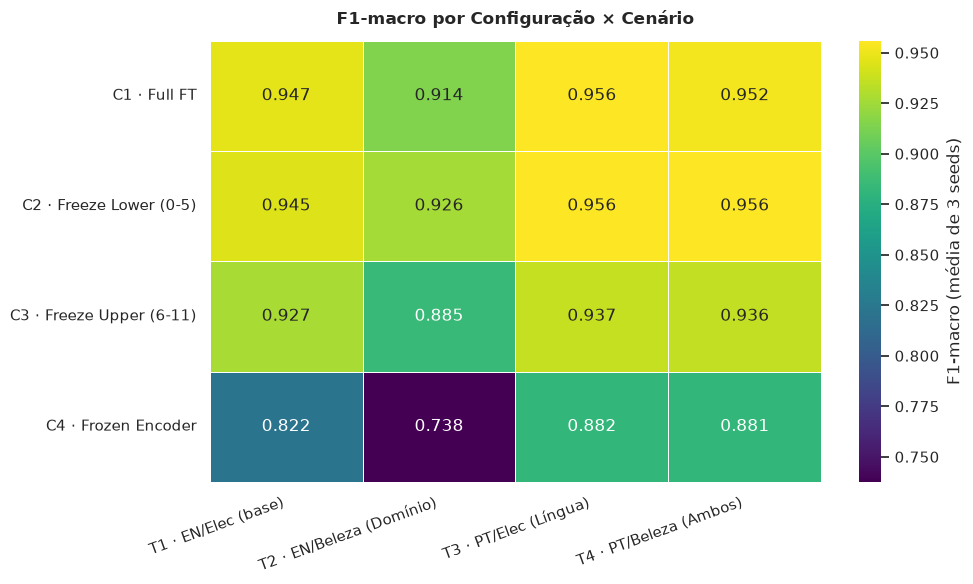

In [6]:
# (1) Heatmap F1-macro: configuração × cenário
hm = media.copy()
hm.index = [NOME_CONFIG[c] for c in hm.index]
hm.columns = [NOME_TESTE[t] for t in hm.columns]
plt.figure(figsize=(10, 6))
ax = sns.heatmap(hm, annot=True, fmt=".3f", cmap="viridis", linewidths=0.5,
                 cbar_kws={"label": "F1-macro (média de 3 seeds)"})
ax.set_title("F1-macro por Configuração × Cenário", weight="bold", pad=12)
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=20, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

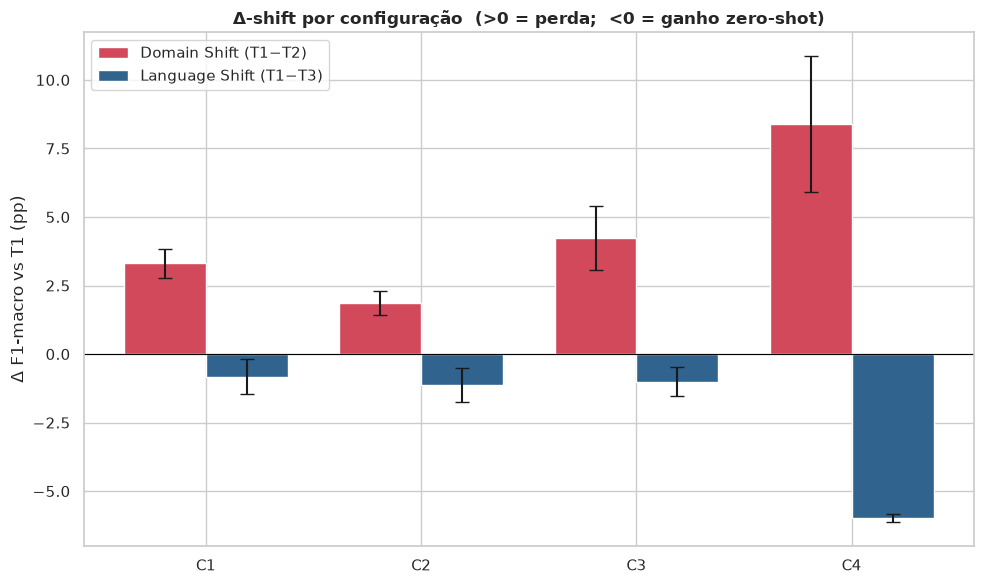

In [7]:
# (2) Barplot dos Δ-shift (Domínio T1−T2 vs Língua T1−T3) com barras de erro
def deltas_seed(cfg, ta, tb):
    a = df[(df.config == cfg) & (df.teste == ta)].sort_values("seed")["f1_macro"].to_numpy()
    b = df[(df.config == cfg) & (df.teste == tb)].sort_values("seed")["f1_macro"].to_numpy()
    return (a - b) * 100

dom_m, dom_s, lin_m, lin_s = [], [], [], []
for c in ORDEM_C:
    dd, dl = deltas_seed(c, "T1", "T2"), deltas_seed(c, "T1", "T3")
    dom_m.append(dd.mean()); dom_s.append(dd.std(ddof=1))
    lin_m.append(dl.mean()); lin_s.append(dl.std(ddof=1))

x = np.arange(len(ORDEM_C)); w = 0.38
plt.figure(figsize=(10, 6))
plt.bar(x - w / 2, dom_m, w, yerr=dom_s, capsize=5, label="Domain Shift (T1−T2)", color="#d1495b")
plt.bar(x + w / 2, lin_m, w, yerr=lin_s, capsize=5, label="Language Shift (T1−T3)", color="#30638e")
plt.axhline(0, color="black", lw=0.8)
plt.xticks(x, ORDEM_C); plt.ylabel("Δ F1-macro vs T1 (pp)")
plt.title("Δ-shift por configuração  (>0 = perda;  <0 = ganho zero-shot)", weight="bold")
plt.legend(); plt.tight_layout(); plt.show()

### Leitura das tabelas

1. **Language Shift nulo (Tabela 3.2, coluna Δ Language).** Em todas as configurações o Δ(T1−T3) é **negativo**: os modelos foram iguais ou melhores em português zero-shot do que no idioma de treino. Não houve degradação de idioma a mitigar.
2. **Domain Shift real (Tabela 3.2, coluna Δ Domain).** Todas as configurações caem ao mudar de Eletrônicos para Beleza; o C1 perde **3,3 pp** (0,947 → 0,914).
3. **C2 mitiga; C3 agrava (Tabelas 3.1 e 3.3).** O C2 (Freeze Lower) marca **0,926** em T2 — acima do full fine-tuning (C1: 0,914; Δ = +1,19 pp, p = 0,086, *d* = +2,45). O C3 (Freeze Upper), aposta original de H2, marca **0,885** (Δ = −2,97 pp, p = 0,074) — a pior estratégia ativa.
4. **Sanidade (Tabela 3.1, linha C4).** O piso (só a head treinável) desaba em todas as células, confirmando que o ajuste do encoder é quem carrega a tarefa.

---
# 4. Conclusão

> Conclusões **amarradas ao escopo e às limitações da Seção 2**. Cada item indica a evidência que o sustenta e o que poderia refutá-lo.

**1. H1 refutada — por inexistência do fenômeno no par EN→PT.** Não há *Language Shift* a mitigar: a baseline C1 não cai ao migrar para o português (Δ T1−T3 = −0,83 pp) e o C2 não altera isso (Δ = +0,03 pp, p = 0,93). A hipótese tornou-se **inaplicável neste par de línguas**, não comprovada nem refutada no mérito.
*Ressalva:* o resultado está confundido com a assimetria de qualidade dos conjuntos (PT é ground-truth; EN é ruidoso — Limitações 1 e 2) e restrito ao par fácil EN→PT (Limitação 3). **Conclusão honesta:** "no par EN↔PT, e dada a assimetria de qualidade, não detectamos *Language Shift*" — **não** "o XLM-R é imune a *Language Shift*".

**2. H2 refutada e invertida — a contribuição central até aqui.** Congelar o topo (C3) **agravou** o *Domain Shift* (0,885 em T2; Δ = −2,97 pp, p = 0,074), enquanto congelar a base (C2) o **mitigou**, superando o full fine-tuning fora de domínio (0,926 vs 0,914). As camadas superiores precisam permanecer livres para formatar a representação da tarefa; a base multilíngue congelada atua como **regularizador** contra o viés lexical do domínio de treino.
*Ressalva:* como T1 e T2 são ambos EN, esta conclusão **não** sofre o confound de idioma; seu escopo é o par de domínios Eletrônicos→Beleza. Como o *Domain Shift* real é maior que o medido (Limitação 1), o efeito protetor de C2 está provavelmente **subestimado**.

**3. C4 (Frozen Encoder) é um piso inviável.** O *probing* linear não basta para a tarefa (colapso em todos os cenários). *Ressalva:* o LR fixo pode subtreinar o C4 (Limitação 8).

**Síntese:** *no XLM-R-base, congelar as camadas iniciais não foi necessário para atravessar idiomas (EN→PT), mas revelou-se um regularizador eficaz para atravessar domínios — o oposto simétrico do que a intuição de BERTology levava a hipotetizar.*

---
# 5. Próximos passos

Encaminhamentos decorrentes das limitações (Metodologia §12), em ordem de prioridade:

1. **Testar em uma língua tipologicamente distante** (ex.: árabe, mandarim ou hindi) — é o teste de refutação da §2.1 da Metodologia e o que separa "robustez real a *Language Shift*" de "artefato do par fácil EN↔PT". **Maior prioridade científica.**
2. **Desambiguar o domínio no lado EN** — trocar o filtro por palavra-chave por um classificador de domínio (ou adotar um dataset EN com categoria), atacando a polissemia (Limitação 1) e removendo o confound de qualidade (Limitação 2).
3. **Partições de freezing mais finas** (só embeddings, só 0–2, etc.) para localizar onde mora o efeito regularizador observado em C2.
4. **Curvas de loss** (Fase 4.3, opcional) a partir dos JSONs `runs/run_*.json` da Etapa 3, para inspecionar convergência e o efeito do early stopping.